# Dataset Inspection: dataset-labeled-anon-ip.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

DATA_PATH = '../../../data/cscas/dataset-labeled-anon-ip.csv'

## 1. Load & Basic Info

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=['Timestamp'])
print(f'Shape: {df.shape}')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

# Per-attribute similarity columns (Tls*, Http*, Dns*, ...) -- everything
# ending in "Similarity" except the aggregate `Similarity`/`SCAS` columns,
# which sections 7/8 already treat separately (see corr_cols below).
sim_cols = [c for c in df.columns if c.endswith('Similarity') and c != 'Similarity']
print(f'{len(sim_cols)} per-attribute similarity columns')

Shape: (1395324, 47)
Memory: 766.7 MB
34 per-attribute similarity columns


## 3. Label Distribution

In [3]:
print('Label value counts:')
print(df['Label'].value_counts())
print(f'\nClass balance: {df["Label"].value_counts(normalize=True).round(4).to_dict()}')

Label value counts:
Label
0    1374372
1      20952
Name: count, dtype: int64

Class balance: {0: 0.985, 1: 0.015}


In [4]:
print('SCAS value counts:')
print(df['SCAS'].value_counts())

SCAS value counts:
SCAS
0    1322652
1      72672
Name: count, dtype: int64


## 4. Temporal Coverage

In [5]:
print(f'Time range: {df["Timestamp"].min()} → {df["Timestamp"].max()}')
print(f'Duration: {df["Timestamp"].max() - df["Timestamp"].min()}')

Time range: 2022-01-20 00:00:03+02:00 → 2022-03-20 23:59:58+02:00
Duration: 59 days 23:59:55


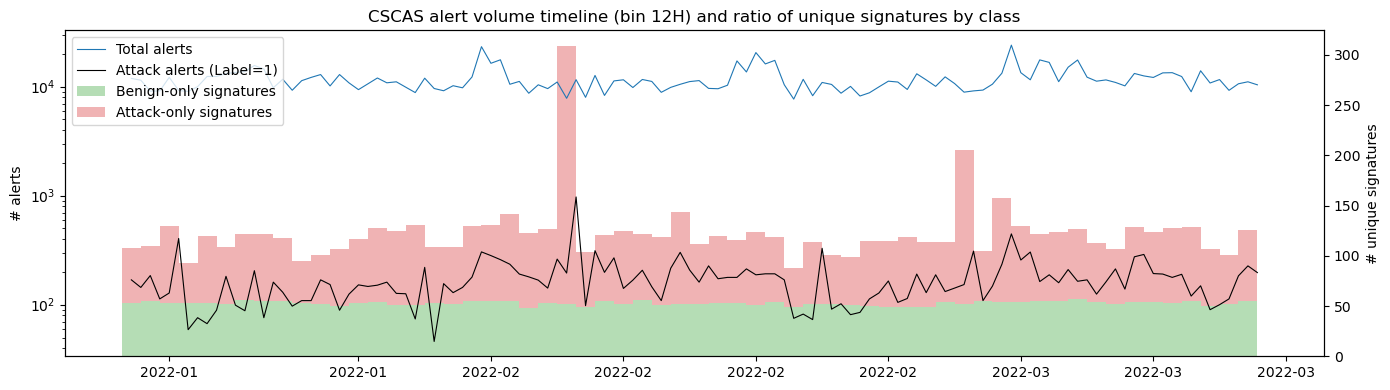

In [6]:
half_daily = df.set_index('Timestamp').resample('12h').agg(
    total=('Label', 'count'),
    attacks=('Label', lambda x: (x == 1).sum())
)

# Classify each signature by the label(s) it has ever appeared with, globally
sig_labels = df.groupby('SignatureID')['Label'].agg(lambda s: set(s))
sig_class = sig_labels.apply(
    lambda s: 'mixed' if len(s) > 1 else ('attack' if 1 in s else 'benign')
)
df['sig_class'] = df['SignatureID'].map(sig_class)

# Unique signatures seen per day, split by their global class
daily_sig_class = (
    df.set_index('Timestamp')
      .groupby([pd.Grouper(freq='D'), 'SignatureID'])['sig_class']
      .first()
      .reset_index()
)
daily_sig_counts = (
    daily_sig_class.groupby(['Timestamp', 'sig_class'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['benign', 'attack', 'mixed'], fill_value=0)
    .reindex(half_daily.index, fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 4))

ax2 = ax.twinx()
bar_kwargs = dict(width=1.0, alpha=0.35, linewidth=0)
ax2.bar(daily_sig_counts.index, daily_sig_counts['benign'],
        label='Benign-only signatures', color='tab:green', **bar_kwargs)
ax2.bar(daily_sig_counts.index, daily_sig_counts['attack'],
        bottom=daily_sig_counts['benign'],
        label='Attack-only signatures', color='tab:red', **bar_kwargs)
# ax2.bar(daily_sig_counts.index, daily_sig_counts['mixed'],
#         bottom=daily_sig_counts['benign'] + daily_sig_counts['attack'],
#         label='Mixed signatures', color='tab:orange', **bar_kwargs)
ax2.set_ylabel('# unique signatures')

# keep line plot drawn on top of the bars
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)

ax.plot(half_daily.index, half_daily['total'], label='Total alerts', linewidth=0.8, color='tab:blue')
ax.plot(half_daily.index, half_daily['attacks'], label='Attack alerts (Label=1)', linewidth=0.8, color='black')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_title('CSCAS alert volume timeline (bin 12H) and ratio of unique signatures by class')
ax.set_ylabel('# alerts')
ax.set_yscale('log')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Signature Analysis

In [7]:
print(f'Unique signatures: {df["SignatureID"].nunique()}')
print(f'Unique signature texts: {df["SignatureText"].nunique()}')

# all unique sigs to file for inspection
df[['SignatureID', 'SignatureText']].drop_duplicates().sort_values('SignatureID').to_csv('unique_signatures.csv', index=False) 

Unique signatures: 587
Unique signature texts: 585


In [8]:
# All signatures by attack rate (min 10 alerts to filter noise)
all_sigs = df.groupby(['SignatureID', 'SignatureText']).agg(
    count=('Label', 'count'),
    attacks=('Label', 'sum'),
    attack_rate=('Label', 'mean')
).query('count >= 10').sort_values('attack_rate', ascending=False)

all_sigs['attack_rate%'] = (all_sigs['attack_rate'] * 100).round(1)
all_sigs[['count', 'attacks', 'attack_rate%']].head()

,,count,attacks,attack_rate%
SignatureID,SignatureText,,,
2025801,ET EXPLOIT file_put_contents php base64 encoded Remote Code Execution 1,10,10,100.0
2030667,ET WEB_SPECIFIC_APPS vBulletin RCE Inbound (CVE-2019-16759 Bypass),259,259,100.0
2027883,ET EXPLOIT FortiOS SSL VPN - Information Disclosure (CVE-2018-13379),16,16,100.0
2028372,ET JA3 Hash - Possible Malware - FiestaEK,44,44,100.0
2029150,ET JA3 Hash - Trojan.AndroidOS.Jocker.snt 1,64,64,100.0


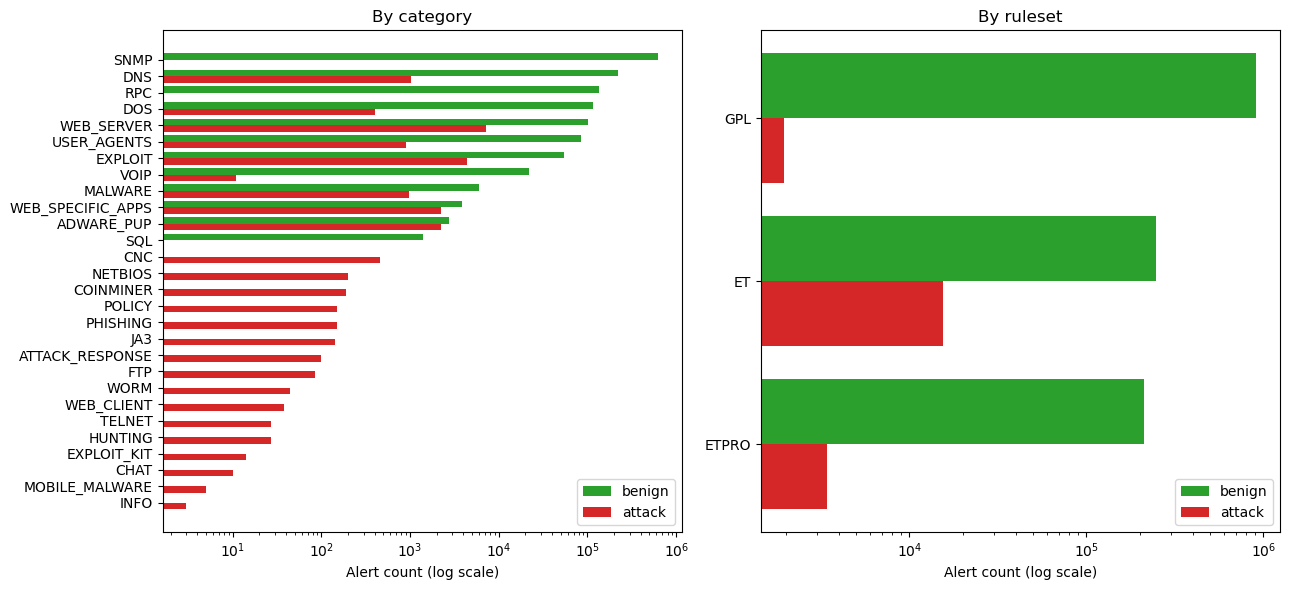

In [9]:
# Alert count by signature "kind" -- ruleset (ET/ETPRO/GPL) and category
# (EXPLOIT/WEB_SERVER/...) -- for benign vs. attack, instead of one bar per
# individual SignatureText. Both are structural prefixes Suricata already
# bakes into SignatureText ("ET EXPLOIT ..."), pulled out via
# parse_signature_text (thesis.preprocessing.suricata_tokenization) -- the
# same single source of truth mining itself uses -- rather than re-deriving
# the split here.
from thesis.preprocessing.suricata_tokenization import parse_signature_text

sig_prefixes = df[['SignatureID', 'SignatureText']].drop_duplicates('SignatureID').copy()
sig_prefixes[['ruleset', 'category', '_desc']] = sig_prefixes['SignatureText'].apply(
    lambda t: pd.Series(parse_signature_text(t), index=['ruleset', 'category', '_desc'])
)
df_kind = df[['SignatureID', 'Label']].merge(
    sig_prefixes[['SignatureID', 'ruleset', 'category']], on='SignatureID', how='left'
)


def counts_by(col):
    g = df_kind.groupby([col, 'Label']).size().unstack(fill_value=0)
    g.columns = ['benign', 'attack']
    return g.assign(total=lambda d: d['benign'] + d['attack']).sort_values('total', ascending=False)


category_counts = counts_by('category')
ruleset_counts = counts_by('ruleset')

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, table, title in [
    (axes[0], category_counts, f'By category'),
    (axes[1], ruleset_counts, 'By ruleset'),
]:
    y = np.arange(len(table))
    ax.barh(y - 0.2, table['benign'], height=0.4, color='tab:green', label='benign')
    ax.barh(y + 0.2, table['attack'], height=0.4, color='tab:red', label='attack')
    ax.set_yticks(y)
    ax.set_yticklabels(table.index)
    ax.invert_yaxis()
    ax.set_xscale('log')
    ax.set_xlabel('Alert count (log scale)')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

Dataset spans 60 days


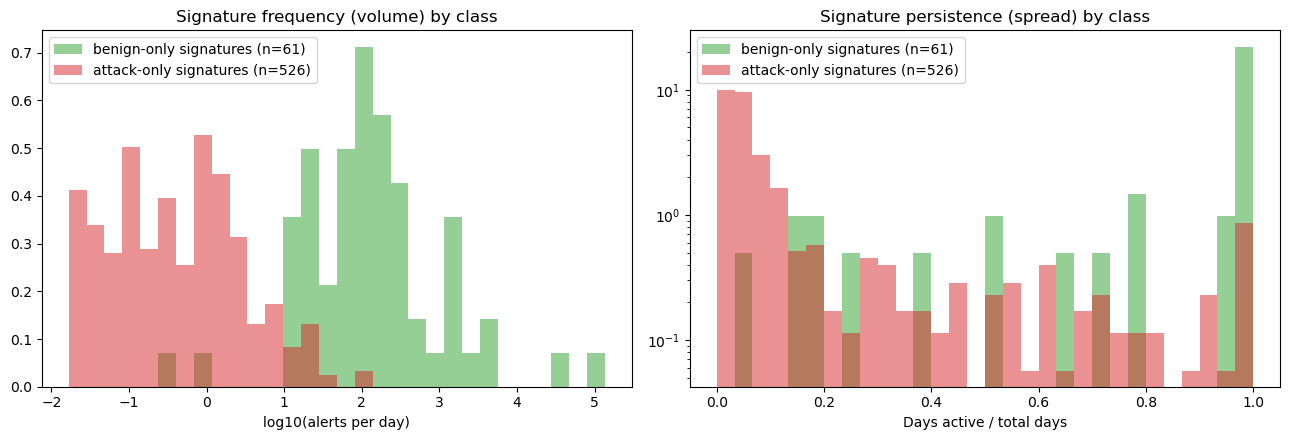

In [10]:
# Per-signature frequency and persistence, split by sig_class (benign-only
# vs. attack-only signatures; mixed dropped -- see section 4).
#
# AlertCount is how many raw alerts each pre-aggregated row represents, so
# total occurrences per signature is groupby(...)['AlertCount'].sum(), not a
# row count. Two distinct notions of "frequency":
#   - alerts/day: volume, normalized over the full dataset timeline.
#   - days active / total days: persistence/spread -- a signature can have
#     huge volume on 3 days (bursty) or moderate volume every day
#     (persistent); the volume figure alone can't tell those apart.
total_days = (df['Timestamp'].max() - df['Timestamp'].min()).days + 1
print(f'Dataset spans {total_days} days')

sig_rate = (df.groupby('SignatureID')['AlertCount'].sum() / total_days).rename('alerts_per_day')

day_col = df['Timestamp'].dt.normalize()
sig_days_active_frac = (day_col.groupby(df['SignatureID']).nunique() / total_days).rename('days_active_frac')

sig_freq = pd.concat([sig_rate, sig_days_active_frac], axis=1).join(sig_class.rename('sig_class'), how='inner')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Histogram log10(alerts_per_day) itself with *linear* bins, rather than
# raw alerts_per_day with log-spaced bins: density=True normalizes by
# (linear) bin width, and log-spaced bins grow exponentially wider at high
# x, so every bin but the narrow low-x ones collapses toward zero height --
# benign spans 0.38-136,403 alerts/day (5.5 orders of magnitude) and looked
# like a single bar for exactly this reason.
log_rate = np.log10(sig_freq['alerts_per_day'])
rate_bins = np.linspace(log_rate.min(), log_rate.max(), 31)

for cls, color in [('benign', 'tab:green'), ('attack', 'tab:red')]:
    grp = sig_freq[sig_freq['sig_class'] == cls]
    label = f'{cls}-only signatures (n={len(grp)})'
    axes[0].hist(np.log10(grp['alerts_per_day']), bins=rate_bins, alpha=0.5, density=True, label=label, color=color)
    axes[1].hist(grp['days_active_frac'], bins=30, range=(0, 1), alpha=0.5, density=True, label=label, color=color)

axes[0].set_xlabel('log10(alerts per day)')
axes[0].set_title('Signature frequency (volume) by class')
axes[0].legend()

axes[1].set_xlabel('Days active / total days')
axes[1].set_title('Signature persistence (spread) by class')
# Log y-axis: 38/61 benign signatures are active on literally every day
# (days_active_frac == 1.0), so that one bin's density (~22) dwarfs the
# rest (0.06-3) on a linear scale -- a real spike in the data, not a
# binning artifact like the left panel's earlier fix.
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
plt.show()

# Scanning associated signatures?

81 signatures have only multi-host (IntIP=-1) rows


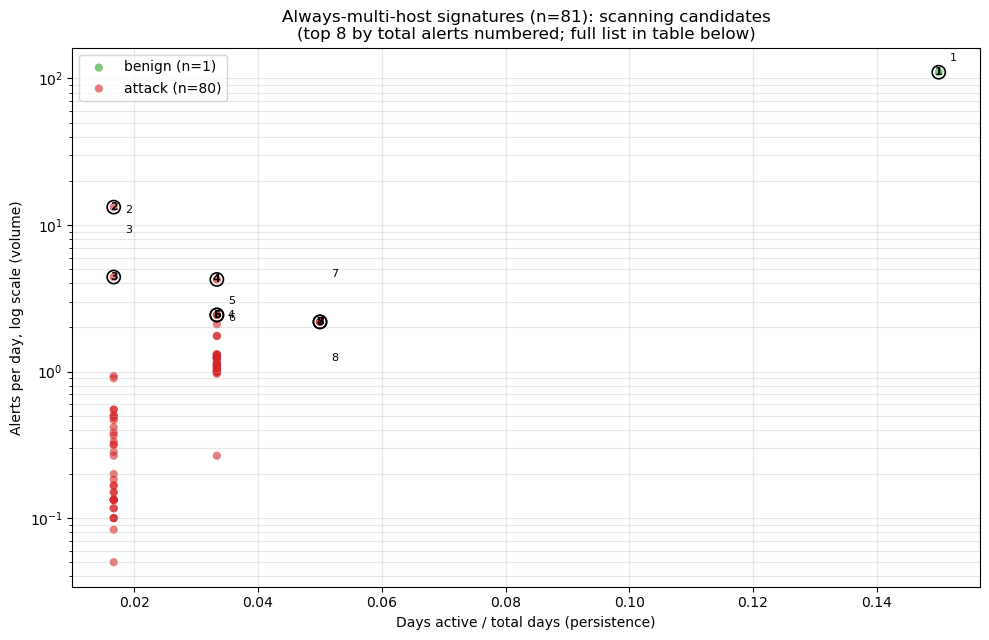

                                                                                                         SignatureText sig_class  total_alerts  alerts_per_day  days_active_frac
#                                                                                                                                                                               
1                                      ET DOS Possible NTP DDoS Inbound Frequent Un-Authed MON_LIST Requests IMPL 0x02    benign          6619      110.316667          0.150000
2                                                                ET WEB_SERVER Observed FxCodeShell Web Shell Password    attack           795       13.250000          0.016667
3                                                       ET EXPLOIT Tomcat File Upload Payload Request (CVE-2017-12615)    attack           265        4.416667          0.016667
4                                                   ET EXPLOIT VMware Spring Cloud Directory Traversal (CVE-2020-54

,SignatureText,sig_class,row_count,total_alerts,alerts_per_day,days_active_frac
SignatureID,,,,,,
2017918,ET DOS Possible NTP DDoS Inbound Frequent Un-Authed MON_...,benign,210,6619,110.316667,0.150000
2027514,ET WEB_SERVER Observed FxCodeShell Web Shell Password,attack,2,795,13.250000,0.016667
2027517,ET EXPLOIT Tomcat File Upload Payload Request (CVE-2017-...,attack,1,265,4.416667,0.016667
2030337,ET EXPLOIT VMware Spring Cloud Directory Traversal (CVE-...,attack,15,255,4.250000,0.033333
2031259,ET EXPLOIT OpenMRS Deserialization Vulnerability CVE-201...,attack,4,146,2.433333,0.033333
...,...,...,...,...,...,...
2015468,ET WEB_SPECIFIC_APPS joomla com_jstore controller parame...,attack,2,6,0.100000,0.016667
2033348,ET EXPLOIT [ConnectWise CRU] Potential Sonicwall SRA SQL...,attack,2,6,0.100000,0.016667
2014837,ET WEB_SPECIFIC_APPS Joomla Jotloader component section ...,attack,2,6,0.100000,0.016667


In [11]:
# Signatures whose alert groups *always* collapse multiple internal hosts
# into one row (IntIP=-1 on every occurrence) are candidate scanning
# signatures -- a single alert group spanning many hosts looks like "probe
# many targets", not "one host got hit repeatedly". Which are they, how
# often do they appear, in what volume, and for which class?
known_ip_df = df[df['IntIP'] != '-1']
host_counts = known_ip_df.groupby('SignatureID')['IntIP'].nunique()
fully_collapsed = sig_class.index.difference(host_counts.index)
print(f'{len(fully_collapsed)} signatures have only multi-host (IntIP=-1) rows')

scanning_sub = df[df['SignatureID'].isin(fully_collapsed)]
scanning_sigs = (
    scanning_sub.groupby(['SignatureID', 'SignatureText'])
    .agg(total_alerts=('AlertCount', 'sum'), row_count=('Label', 'count'))
    .reset_index()
    .set_index('SignatureID')
)
scanning_sigs['sig_class'] = sig_class.reindex(scanning_sigs.index)
scanning_sigs['alerts_per_day'] = sig_rate.reindex(scanning_sigs.index)
scanning_sigs['days_active_frac'] = sig_days_active_frac.reindex(scanning_sigs.index)
scanning_sigs = scanning_sigs.sort_values('total_alerts', ascending=False)

N_LABEL = 8  # top-N by total_alerts get a numbered marker + table row

fig, ax = plt.subplots(figsize=(10, 6.5))
for cls, color in [('benign', 'tab:green'), ('attack', 'tab:red')]:
    grp = scanning_sigs[scanning_sigs['sig_class'] == cls]
    ax.scatter(grp['days_active_frac'], grp['alerts_per_day'], color=color, alpha=0.6,
               edgecolors='none', s=35, label=f'{cls} (n={len(grp)})')

# Numbered markers instead of raw text -- avoids overlap and long strings.
top = scanning_sigs.head(N_LABEL).reset_index()
texts = []
for i, row in top.iterrows():
    x, y = row['days_active_frac'], row['alerts_per_day']
    ax.scatter([x], [y], facecolors='none', edgecolors='black', s=90, linewidths=1.2, zorder=5)
    t = ax.annotate(str(i + 1), (x, y), fontsize=8, fontweight='bold',
                     ha='center', va='center', zorder=6)
    texts.append(ax.annotate(str(i + 1), (x, y), fontsize=8, xytext=(6, 6),
                              textcoords='offset points'))

try:
    from adjustText import adjust_text
    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
except ImportError:
    # Fallback: spread labels vertically by rank so they don't stack.
    for i, t in enumerate(texts):
        t.set_position((8, 8 + (i % 4) * 12 * (1 if i % 2 == 0 else -1)))

ax.set_yscale('log')
ax.set_xlabel('Days active / total days (persistence)')
ax.set_ylabel('Alerts per day, log scale (volume)')
ax.set_title(f'Always-multi-host signatures (n={len(scanning_sigs)}): scanning candidates\n'
             f'(top {N_LABEL} by total alerts numbered; full list in table below)')
ax.grid(alpha=0.3, which='both')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Mapping table for the numbered markers, plus full results below.
top_display = top.copy()
top_display.index = top_display.index + 1
top_display.index.name = '#'
print(top_display[['SignatureText', 'sig_class', 'total_alerts', 'alerts_per_day', 'days_active_frac']]
      .to_string())

scanning_sigs[['SignatureText', 'sig_class', 'row_count', 'total_alerts', 'alerts_per_day', 'days_active_frac']]

## 6. Protocol & Port Distribution

In [12]:
print('Protocol value counts (top 10):')
print(df['Proto'].value_counts().head(10))

Protocol value counts (top 10):
Proto
 17    1128587
 6      266497
-1         129
 1         111
Name: count, dtype: int64


## 7. Similarity Feature Overview

In [13]:
# Replace -1 with NaN for stats on real similarity values
sim_df = df[sim_cols].replace(-1, np.nan)
sim_stats = sim_df.describe().T
sim_stats['coverage%'] = (sim_df.notna().mean() * 100).round(1)
sim_stats[['coverage%', 'mean', 'std', 'min', 'max']].sort_values('coverage%', ascending=False)

,coverage%,mean,std,min,max
AppProtoSimilarity,100.0,0.973877,0.117820,0.0,1.000000
ExtIPSimilarity,100.0,0.651323,0.439495,0.0,1.000000
SignatureIDSimilarity,100.0,0.974809,0.145852,0.0,1.000000
ProtoSimilarity,100.0,0.990791,0.067556,0.0,1.000000
IntPortSimilarity,100.0,0.962686,0.162492,0.0,1.000000
ExtPortSimilarity,100.0,0.886974,0.304143,0.0,1.000000
IntIPSimilarity,100.0,0.812993,0.352345,0.0,1.000000
HttpHostnameSimilarity,18.7,0.384213,0.405277,0.0,1.000000
HttpMethodSimilarity,18.7,0.759111,0.280818,0.0,1.000000
HttpProtocolSimilarity,18.7,0.844377,0.253793,0.0,1.000000


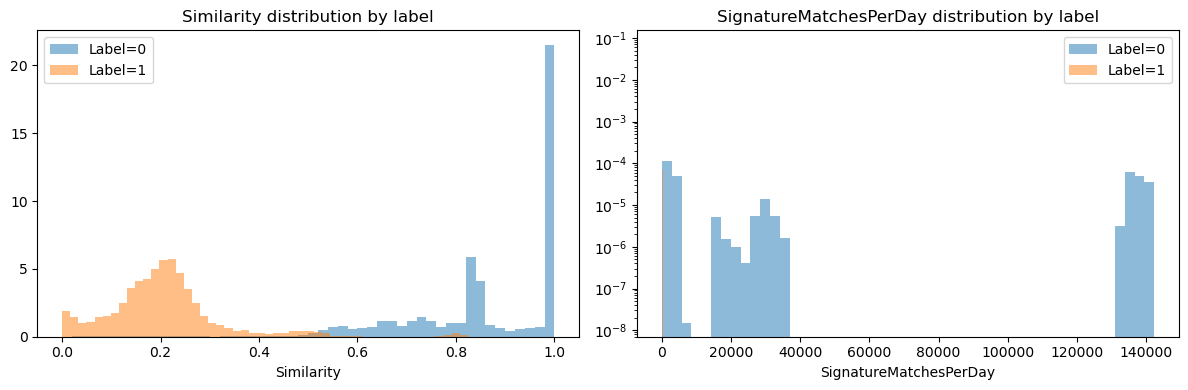

In [14]:
# Distribution of SCAS (aggregate similarity)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, grp in df.groupby('Label'):
    axes[0].hist(grp['Similarity'], bins=50, alpha=0.5, density=True, label=f'Label={label}')
axes[0].set_title('Similarity distribution by label')
axes[0].set_xlabel('Similarity')
axes[0].legend()

for label, grp in df.groupby('Label'):
    axes[1].hist(grp['SignatureMatchesPerDay'], bins=50, alpha=0.5, density=True, label=f'Label={label}')
axes[1].set_title('SignatureMatchesPerDay distribution by label')
axes[1].set_xlabel('SignatureMatchesPerDay')
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
plt.show()

## 15. Dataset-level EDA (run_eda / run_eda_host parity)

Reproduces the analysis + plots from the old `run_eda.py` script for the `cscas` dataset (a single pre-grouped scenario, also named `cscas`), via `thesis.data.eda` (computation) and `thesis.visualization.eda` (plotting). No per-host section here -- cscas rows have no `host` column, that analysis is AIT-ADS only. Output is written under `artifacts/experiments/run_eda/cscas/`, same layout the script used.

In [15]:
import sys
from datetime import datetime, timezone
from pathlib import Path

REPO2 = Path.cwd().resolve().parents[2]
sys.path.insert(0, str(REPO2 / 'src'))

import thesis.data.eda as de
from thesis.configs import load_scenarios
from thesis.visualization.eda import load_alerts, plot_label_distribution_table

DATASET2 = 'cscas'
DATA_DIR2 = REPO2 / 'data' / 'cscas'
scenarios2 = load_scenarios(DATASET2)
print(f'Scenarios: {scenarios2}')

run_ts2 = datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S')
run_dir2 = REPO2 / 'artifacts' / 'experiments' / 'run_eda' / DATASET2 / f'run_{run_ts2}_raw'
summary_dir2 = run_dir2 / 'summary'
print(f'Output dir: {run_dir2}')

Scenarios: ['cscas']
Output dir: /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/run_eda/cscas/run_20260711_153506_raw


### Load alerts

In [16]:
all_df2 = load_alerts(str(DATA_DIR2), scenarios=scenarios2, dataset=DATASET2)
print(f'{len(all_df2):,} alerts loaded.')
all_df2.head()

1,395,324 alerts loaded.


,Timestamp,SignatureText,SignatureID,SignatureMatchesPerDay,AlertCount,Proto,ExtIP,ExtPort,IntIP,IntPort,Similarity,Label,SCAS,AppProtoSimilarity,DnsRrnameSimilarity,DnsRrtypeSimilarity,EmailFromSimilarity,EmailStatusSimilarity,EmailToSimilarity,ExtIPSimilarity,ExtPortSimilarity,HttpContentTypeSimilarity,HttpHostnameSimilarity,HttpMethodSimilarity,HttpProtocolSimilarity,HttpRequestBodySimilarity,HttpResponseBodySimilarity,HttpStatusSimilarity,HttpUrlSimilarity,HttpUserAgentSimilarity,IntIPSimilarity,IntPortSimilarity,ProtoSimilarity,SignatureIDSimilarity,SmtpHeloSimilarity,SmtpMailFromSimilarity,SmtpRcptToSimilarity,SshClientProtoSimilarity,SshClientSoftwareSimilarity,SshServerProtoSimilarity,SshServerSoftwareSimilarity,TlsFingerprintSimilarity,TlsIssuerDnSimilarity,TlsJa3hashSimilarity,TlsSniSimilarity,TlsSubjectSimilarity,TlsVersionSimilarity,timestamp,time,scenario,is_attack,label,signature,ip
0,2022-01-20T00:00:03+02:00,GPL SNMP public access udp,2101411,140201.481767,4,17,extip1,57239,-1,161,0.998231,0,0,0.989388,-1.0,-1.0,-1,-1,-1,1.000000,1.00000,-1.0,-1.0,-1.0,-1.000000,-1.0,-1.0,-1.0,-1.000000,-1.000000,1.0,1.000000,1.0,1.0,-1,-1,-1,-1,-1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,2022-01-19 22:00:03+00:00,1642629603,cscas,False,false_positive,GPL SNMP public access udp,extip1
1,2022-01-20T00:00:13+02:00,GPL SNMP public access udp,2101411,140201.525122,1,17,extip2,32050,intip1,161,0.998249,0,0,0.989494,-1.0,-1.0,-1,-1,-1,1.000000,1.00000,-1.0,-1.0,-1.0,-1.000000,-1.0,-1.0,-1.0,-1.000000,-1.000000,1.0,1.000000,1.0,1.0,-1,-1,-1,-1,-1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,2022-01-19 22:00:13+00:00,1642629613,cscas,False,false_positive,GPL SNMP public access udp,extip2
2,2022-01-20T00:00:17+02:00,ET VOIP REGISTER Message Flood UDP,2009699,298.864011,1,17,extip3,9999,intip2,5060,0.505563,0,0,1.000000,-1.0,-1.0,-1,-1,-1,0.016690,0.01669,-1.0,-1.0,-1.0,-1.000000,-1.0,-1.0,-1.0,-1.000000,-1.000000,0.0,1.000000,1.0,1.0,-1,-1,-1,-1,-1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,2022-01-19 22:00:17+00:00,1642629617,cscas,False,false_positive,ET VOIP REGISTER Message Flood UDP,extip3
3,2022-01-20T00:00:31+02:00,ET EXPLOIT D-Link Devices Home Network Administration Pr...,2020899,841.202279,1,6,extip4,44774,intip3,80,0.725752,0,0,1.000000,-1.0,-1.0,-1,-1,-1,0.524855,1.00000,0.0,1.0,1.0,0.782562,0.0,1.0,0.0,0.900447,0.683009,1.0,0.995414,1.0,1.0,-1,-1,-1,-1,-1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,2022-01-19 22:00:31+00:00,1642629631,cscas,False,false_positive,ET EXPLOIT D-Link Devices Home Network Administration Pr...,extip4
4,2022-01-20T00:00:31+02:00,ET WEB_SERVER WGET Command Specifying Output in HTTP Hea...,2019309,841.311867,1,6,extip4,44774,intip3,80,0.725752,0,0,1.000000,-1.0,-1.0,-1,-1,-1,0.524855,1.00000,0.0,1.0,1.0,0.782560,0.0,1.0,0.0,0.900447,0.683007,1.0,0.995414,1.0,1.0,-1,-1,-1,-1,-1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,2022-01-19 22:00:31+00:00,1642629631,cscas,False,false_positive,ET WEB_SERVER WGET Command Specifying Output in HTTP Hea...,extip4


### Phase 1: per-scenario analysis

cscas is pre-grouped (one row per already-aggregated basket, not a raw alert-by-alert stream), so alert_group pair-frequency analysis doesn't apply here (`skip_grouping=True`) -- this just writes the per-scenario text summary (basic stats, missing values, label distribution, top signatures).

In [17]:
for scenario in scenarios2:
    scenario_df2 = all_df2[all_df2['scenario'] == scenario].copy()
    de.run_scenario_eda(
        scenario_df2,
        scenario,
        out_path=run_dir2 / scenario,
        summary_path=summary_dir2,
        alert_groups_base_dir=REPO2 / 'artifacts' / 'alert_groups',
        skip_grouping=True,
    )
    del scenario_df2

  Running EDA for scenario 'cscas' (n=1,395,324 rows)...
  cscas: done → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/run_eda/cscas/run_20260711_153506_raw/cscas


### Cross-scenario tables

cscas has a single scenario, so these tables have one row -- still useful as the same standardized summary the AIT-ADS notebook produces.

In [18]:
overview_df2 = de.compute_overview_table(all_df2)
overview_df2.to_csv(run_dir2 / 'overview_table.csv', index=False)
overview_df2

,scenario,start,end,duration_days,total_alerts,benign_alerts,attack_alerts,attack_pct,unique_signatures,attack_types
0,cscas,2022-01-19,2022-03-20,60.0,1395324,1374372,20952,1.5,585,1


In [19]:
label_dist_df2 = de.compute_label_distribution_table(all_df2)
label_dist_df2.to_csv(run_dir2 / 'label_distribution_table.csv', index=False)

### Phase 2: overview plots

cscas-specific plots (temporal attack overview, signature event raster, signature purity pie) plus the shared overview plots (class balance, attack-type heatmap, top signatures, inter-arrival CDF, group size distribution, scenario overview table). No alert_group volume plots -- cscas skipped alert_group construction above.

In [20]:
plots2 = de.build_overview_plots(scenarios2, all_df2, dataset=DATASET2, groups_df=None)
de.save_overview_plots(plots2, run_dir2 / 'plots', de.data_label(), close=True)

/Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/visualization/eda.py:1275: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=(0, 0, 1, 0.97))



[plots] Saving to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/run_eda/cscas/run_20260711_153506_raw/plots
  Saving temporal attack overview... done
  Saving signature event raster... done
  Saving signature_burst_raster... done
  Saving signature purity pie... done
  Saving class balance... done
  Saving attack type heatmap... done
  Saving top alert signatures... done
  Saving inter-arrival time CDF... done
  Saving group size distribution... done
  Saving scenario overview table... done


In [21]:
# Free the section-15 copies before section 16 reloads df from scratch --
# all_df2/plots2 are full-size duplicates of the CSV and otherwise sit in
# memory unused for the rest of the run.
import gc

del all_df2, plots2
gc.collect()

158293

## 16. Field/Feature Overview — Summary CSVs

Tabular numerical overview of the raw dataset's fields, written to `overview_csvs/` next to this notebook: signature behavior (always-benign / always-attack / mixed, CVE coverage, per-day and per-hour activity), and network fields (IP/port/protocol cardinality and the `-1` "multiple values aggregated into this row" sentinel). Reloads `df` fresh from `DATA_PATH` so it's independent of whatever the preceding sections left `df` as.

In [22]:
from pathlib import Path

df = pd.read_csv(DATA_PATH, parse_dates=['Timestamp'])

OVERVIEW_DIR = Path('overview_csvs')
OVERVIEW_DIR.mkdir(exist_ok=True)
print(f'Writing overview CSVs to {OVERVIEW_DIR.resolve()}')
print(f'{len(df):,} rows')

Writing overview CSVs to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/notebooks/overview_csvs
1,395,324 rows


### 16.1 Signature analysis

Per-signature stats (count, benign/attack split, always-benign / always-attack / mixed classification, days/hours active, CVE refs), plus dataset-level rollups.

In [23]:
sig_stats = df.groupby(['SignatureID', 'SignatureText']).agg(
    count=('Label', 'count'),
    attack_count=('Label', 'sum'),
).reset_index()
sig_stats['benign_count'] = sig_stats['count'] - sig_stats['attack_count']
sig_stats['attack_rate%'] = (sig_stats['attack_count'] / sig_stats['count'] * 100).round(3)
sig_stats['sig_class'] = np.select(
    [sig_stats['attack_count'] == 0, sig_stats['benign_count'] == 0],
    ['always_benign', 'always_attack'],
    default='mixed',
)

span = df.groupby('SignatureID').agg(
    n_days_active=('Timestamp', lambda s: s.dt.normalize().nunique()),
    n_hours_active=('Timestamp', lambda s: s.dt.floor('h').nunique()),
    first_seen=('Timestamp', 'min'),
    last_seen=('Timestamp', 'max'),
).reset_index()
sig_stats = sig_stats.merge(span, on='SignatureID')

# Attach CVE refs / category from the tokenization output (section 10), if it has been run.
try:
    tok = pd.read_csv('tokenized_signatures2.csv')
    sig_stats = sig_stats.merge(
        tok[['signature_id', 'cve_refs', 'category']].rename(columns={'signature_id': 'SignatureID'}),
        on='SignatureID', how='left',
    )
except FileNotFoundError:
    sig_stats['cve_refs'] = None
    sig_stats['category'] = None

sig_stats = sig_stats.sort_values('count', ascending=False)
sig_stats.to_csv(OVERVIEW_DIR / 'signature_overview.csv', index=False)
print(f'{len(sig_stats)} signatures -> signature_overview.csv')
sig_stats.head()

587 signatures -> signature_overview.csv


,SignatureID,SignatureText,count,attack_count,benign_count,attack_rate%,sig_class,n_days_active,n_hours_active,first_seen,last_seen,cve_refs,category
459,2101411,GPL SNMP public access udp,592445,0,592445,0.0,always_benign,60,1440,2022-01-20 00:00:03+02:00,2022-03-20 23:59:58+02:00,NaN,SNMP
461,2101616,GPL DNS named version attempt,135622,0,135622,0.0,always_benign,60,1440,2022-01-20 00:02:02+02:00,2022-03-20 23:56:53+02:00,NaN,DNS
462,2101867,GPL RPC xdmcp info query,135350,0,135350,0.0,always_benign,60,1440,2022-01-20 00:11:31+02:00,2022-03-20 23:58:33+02:00,NaN,RPC
558,2842116,ETPRO USER_AGENTS Observed Suspicious UA (Mozilla/5.0),84112,0,84112,0.0,always_benign,60,1440,2022-01-20 00:03:11+02:00,2022-03-20 23:59:55+02:00,NaN,USER_AGENTS
512,2812543,ETPRO DOS Possible RPC Portmapper Scanning,82503,0,82503,0.0,always_benign,60,987,2022-01-20 05:33:44+02:00,2022-03-20 23:28:45+02:00,NaN,DOS


In [24]:
all_cves = set()
if sig_stats['cve_refs'].notna().any():
    for refs in sig_stats['cve_refs'].dropna():
        if refs:
            all_cves.update(refs.split('|'))

signature_summary = pd.DataFrame([{
    'n_unique_signatures': sig_stats['SignatureID'].nunique(),
    'n_always_benign_signatures': int((sig_stats['sig_class'] == 'always_benign').sum()),
    'n_always_attack_signatures': int((sig_stats['sig_class'] == 'always_attack').sum()),
    'n_mixed_signatures': int((sig_stats['sig_class'] == 'mixed').sum()),
    'n_unique_cves': len(all_cves),
}])
signature_summary.to_csv(OVERVIEW_DIR / 'signature_summary.csv', index=False)
signature_summary

,n_unique_signatures,n_always_benign_signatures,n_always_attack_signatures,n_mixed_signatures,n_unique_cves
0,587,61,526,0,116


### 16.2 Signature activity per day / per hour

For each calendar-day and each hourly bin: how many distinct signatures were active, split by their global class (`always_benign` / `always_attack` / `mixed`), and what fraction of that bin's active signatures each class represents. `signature_activity_summary.csv` collapses each series to min/max/mean.

In [25]:
sig_class_map = sig_stats.set_index('SignatureID')['sig_class']
df['_sig_overview_class'] = df['SignatureID'].map(sig_class_map)


def signature_activity_by_bin(freq):
    binned = df[['Timestamp', 'SignatureID', '_sig_overview_class']].copy()
    binned['bin'] = binned['Timestamp'].dt.floor(freq)
    active = binned.groupby(['bin', 'SignatureID'])['_sig_overview_class'].first().reset_index()
    counts = (
        active.groupby(['bin', '_sig_overview_class'])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=['always_benign', 'always_attack', 'mixed'], fill_value=0)
    )
    counts['n_active_signatures'] = counts.sum(axis=1)
    counts['frac_benign'] = counts['always_benign'] / counts['n_active_signatures']
    counts['frac_attack'] = counts['always_attack'] / counts['n_active_signatures']
    counts['frac_mixed'] = counts['mixed'] / counts['n_active_signatures']
    return counts.reset_index().rename(columns={'bin': 'Timestamp'})


daily_sig_activity = signature_activity_by_bin('D')
hourly_sig_activity = signature_activity_by_bin('h')

daily_sig_activity.to_csv(OVERVIEW_DIR / 'signature_activity_per_day.csv', index=False)
hourly_sig_activity.to_csv(OVERVIEW_DIR / 'signature_activity_per_hour.csv', index=False)

print(f'{len(daily_sig_activity)} daily bins -> signature_activity_per_day.csv')
print(f'{len(hourly_sig_activity)} hourly bins -> signature_activity_per_hour.csv')
daily_sig_activity.head()

60 daily bins -> signature_activity_per_day.csv
1440 hourly bins -> signature_activity_per_hour.csv


_sig_overview_class,Timestamp,always_benign,always_attack,mixed,n_active_signatures,frac_benign,frac_attack,frac_mixed
0,2022-01-20 00:00:00+02:00,53,55,0,108,0.490741,0.509259,0.0
1,2022-01-21 00:00:00+02:00,55,55,0,110,0.500000,0.500000,0.0
2,2022-01-22 00:00:00+02:00,53,77,0,130,0.407692,0.592308,0.0
3,2022-01-23 00:00:00+02:00,53,40,0,93,0.569892,0.430108,0.0
4,2022-01-24 00:00:00+02:00,53,67,0,120,0.441667,0.558333,0.0


In [26]:
def summarize_activity(counts_df, granularity):
    cols = ['always_benign', 'always_attack', 'mixed', 'n_active_signatures',
            'frac_benign', 'frac_attack', 'frac_mixed']
    return [
        {
            'granularity': granularity,
            'metric': col,
            'min': counts_df[col].min(),
            'max': counts_df[col].max(),
            'mean': counts_df[col].mean(),
        }
        for col in cols
    ]


signature_activity_summary = pd.DataFrame(
    summarize_activity(daily_sig_activity, 'day') + summarize_activity(hourly_sig_activity, 'hour')
)
signature_activity_summary[['min', 'max', 'mean']] = signature_activity_summary[['min', 'max', 'mean']].round(4)
signature_activity_summary.to_csv(OVERVIEW_DIR / 'signature_activity_summary.csv', index=False)
signature_activity_summary

,granularity,metric,min,max,mean
0,day,always_benign,48.0000,57.0000,52.7667
1,day,always_attack,39.0000,257.0000,69.8333
2,day,mixed,0.0000,0.0000,0.0000
3,day,n_active_signatures,88.0000,309.0000,122.6000
4,day,frac_benign,0.1683,0.5699,0.4439
5,day,frac_attack,0.4301,0.8317,0.5561
6,day,frac_mixed,0.0000,0.0000,0.0000
7,hour,always_benign,21.0000,43.0000,31.7778
8,hour,always_attack,0.0000,200.0000,8.1465
9,hour,mixed,0.0000,0.0000,0.0000


### 16.3 Network fields — IP / port / protocol

Cardinality of `IntIP`, `ExtIP`, `Proto`, `IntPort`, `ExtPort`, plus how often each field's `-1` sentinel appears (meaning: the underlying session/basket touched *multiple* distinct values for that field, not resolvable to one).

In [27]:
def multi_row_stats(series, sentinel):
    is_multi = series == sentinel
    return int(is_multi.sum()), round(float(is_multi.mean()) * 100, 3)


n_multi_int_ip, pct_multi_int_ip = multi_row_stats(df['IntIP'], '-1')
n_multi_ext_ip, pct_multi_ext_ip = multi_row_stats(df['ExtIP'], '-1')
n_multi_proto, pct_multi_proto = multi_row_stats(df['Proto'], -1)
n_multi_int_port, pct_multi_int_port = multi_row_stats(df['IntPort'], -1)
n_multi_ext_port, pct_multi_ext_port = multi_row_stats(df['ExtPort'], -1)

network_overview = pd.DataFrame([{
    'total_rows': len(df),
    'n_distinct_int_ip': df.loc[df['IntIP'] != '-1', 'IntIP'].nunique(),
    'n_rows_multi_int_ip': n_multi_int_ip,
    'pct_rows_multi_int_ip': pct_multi_int_ip,
    'n_distinct_ext_ip': df.loc[df['ExtIP'] != '-1', 'ExtIP'].nunique(),
    'n_rows_multi_ext_ip': n_multi_ext_ip,
    'pct_rows_multi_ext_ip': pct_multi_ext_ip,
    'n_distinct_protocols': df.loc[df['Proto'] != -1, 'Proto'].nunique(),
    'n_rows_multi_proto': n_multi_proto,
    'pct_rows_multi_proto': pct_multi_proto,
    'n_distinct_int_ports': df.loc[df['IntPort'] != -1, 'IntPort'].nunique(),
    'n_rows_multi_int_port': n_multi_int_port,
    'pct_rows_multi_int_port': pct_multi_int_port,
    'n_distinct_ext_ports': df.loc[df['ExtPort'] != -1, 'ExtPort'].nunique(),
    'n_rows_multi_ext_port': n_multi_ext_port,
    'pct_rows_multi_ext_port': pct_multi_ext_port,
}])
network_overview.to_csv(OVERVIEW_DIR / 'network_field_overview.csv', index=False)
network_overview.T

,0
total_rows,1395324.000
n_distinct_int_ip,4401.000
n_rows_multi_int_ip,330352.000
pct_rows_multi_int_ip,23.676
n_distinct_ext_ip,45339.000
n_rows_multi_ext_ip,0.000
pct_rows_multi_ext_ip,0.000
n_distinct_protocols,3.000
n_rows_multi_proto,129.000
pct_rows_multi_proto,0.009


In [28]:
proto_dist = df.groupby('Proto').agg(
    count=('Label', 'count'),
    attack_count=('Label', 'sum'),
).reset_index()
proto_dist['pct_of_rows'] = (proto_dist['count'] / len(df) * 100).round(3)
proto_dist['attack_rate%'] = (proto_dist['attack_count'] / proto_dist['count'] * 100).round(3)
proto_dist = proto_dist.sort_values('count', ascending=False)
proto_dist.to_csv(OVERVIEW_DIR / 'protocol_distribution.csv', index=False)
proto_dist

,Proto,count,attack_count,pct_of_rows,attack_rate%
3,17,1128587,483,80.884,0.043
2,6,266497,20352,19.099,7.637
0,-1,129,6,0.009,4.651
1,1,111,111,0.008,100.000


In [29]:
def top_ports(col, n=25):
    sub = df[df[col] != -1]
    t = sub.groupby(col).agg(
        count=('Label', 'count'),
        attack_count=('Label', 'sum'),
    ).sort_values('count', ascending=False).head(n).reset_index()
    t['pct_of_rows'] = (t['count'] / len(df) * 100).round(4)
    t['attack_rate%'] = (t['attack_count'] / t['count'] * 100).round(3)
    return t


top_int_ports = top_ports('IntPort')
top_ext_ports = top_ports('ExtPort')
top_int_ports.to_csv(OVERVIEW_DIR / 'top_int_ports.csv', index=False)
top_ext_ports.to_csv(OVERVIEW_DIR / 'top_ext_ports.csv', index=False)
print('Top 10 internal ports:')
print(top_int_ports.head(10))

Top 10 internal ports:
   IntPort   count  attack_count  pct_of_rows  attack_rate%
0      161  628298             0      45.0288         0.000
1       80  158395         10540      11.3518         6.654
2       53  138997          1025       9.9616         0.737
3      177  135350             0       9.7003         0.000
4      111   82503             0       5.9128         0.000
5     5060   22143            11       1.5869         0.050
6      123   21563             0       1.5454         0.000
7     1900    8236             0       0.5903         0.000
8     8008    3770          1383       0.2702        36.684
9     8090    3072            30       0.2202         0.977


### 16.3b Port bucket distribution

Ports classified into IANA-style ranges: `well_known (0-1023)`, `registered (1024-49151)`, `ephemeral (49152-65535)`, plus the `-1` "multiple ports aggregated into this row" sentinel.

In [30]:
def port_bucket_series(port_col):
    conditions = [
        port_col == -1,
        port_col < 1024,
        port_col < 49152,
    ]
    choices = ['multiple (-1)', 'well_known (0-1023)', 'registered (1024-49151)']
    return pd.Series(np.select(conditions, choices, default='ephemeral (49152-65535)'), index=port_col.index)


BUCKET_ORDER = ['well_known (0-1023)', 'registered (1024-49151)', 'ephemeral (49152-65535)', 'multiple (-1)']


def port_bucket_distribution(col):
    bucket = port_bucket_series(df[col])
    dist = (
        pd.DataFrame({'bucket': bucket, 'Label': df['Label']})
        .groupby('bucket')
        .agg(count=('Label', 'count'), attack_count=('Label', 'sum'))
        .reindex(BUCKET_ORDER, fill_value=0)
    )
    dist['pct_of_rows'] = (dist['count'] / len(df) * 100).round(3)
    dist['attack_rate%'] = (dist['attack_count'] / dist['count'] * 100).round(3)
    return dist.reset_index()


port_bucket_dist = pd.concat([
    port_bucket_distribution('IntPort').assign(port_type='internal'),
    port_bucket_distribution('ExtPort').assign(port_type='external'),
], ignore_index=True)
port_bucket_dist = port_bucket_dist[['port_type', 'bucket', 'count', 'attack_count', 'pct_of_rows', 'attack_rate%']]
port_bucket_dist.to_csv(OVERVIEW_DIR / 'port_bucket_distribution.csv', index=False)

print(port_bucket_dist.to_string(index=False))

port_type                  bucket   count  attack_count  pct_of_rows  attack_rate%
 internal     well_known (0-1023) 1168645         13489       83.754         1.154
 internal registered (1024-49151)   64896          2833        4.651         4.365
 internal ephemeral (49152-65535)   85256          2700        6.110         3.167
 internal           multiple (-1)   76527          1930        5.485         2.522
 external     well_known (0-1023)  191191          4670       13.702         2.443
 external registered (1024-49151)  577183          5911       41.366         1.024
 external ephemeral (49152-65535)  389569          4010       27.920         1.029
 external           multiple (-1)  237381          6361       17.013         2.680


### 16.4 Dataset-level rollup

One row tying the sections above together — the single table to skim first.

In [31]:
dataset_overview = pd.DataFrame([{
    'total_rows': len(df),
    'start': df['Timestamp'].min(),
    'end': df['Timestamp'].max(),
    'duration_days': round((df['Timestamp'].max() - df['Timestamp'].min()).total_seconds() / 86400, 1),
    'n_benign_rows': int((df['Label'] == 0).sum()),
    'n_attack_rows': int((df['Label'] == 1).sum()),
    'attack_rate%': round((df['Label'] == 1).mean() * 100, 3),
    'n_unique_signatures': signature_summary['n_unique_signatures'].iloc[0],
    'n_always_benign_signatures': signature_summary['n_always_benign_signatures'].iloc[0],
    'n_always_attack_signatures': signature_summary['n_always_attack_signatures'].iloc[0],
    'n_mixed_signatures': signature_summary['n_mixed_signatures'].iloc[0],
    'n_unique_cves': signature_summary['n_unique_cves'].iloc[0],
    'n_distinct_int_ip': network_overview['n_distinct_int_ip'].iloc[0],
    'n_distinct_ext_ip': network_overview['n_distinct_ext_ip'].iloc[0],
    'n_distinct_protocols': network_overview['n_distinct_protocols'].iloc[0],
    'n_distinct_int_ports': network_overview['n_distinct_int_ports'].iloc[0],
    'n_distinct_ext_ports': network_overview['n_distinct_ext_ports'].iloc[0],
}])
dataset_overview.to_csv(OVERVIEW_DIR / 'dataset_overview.csv', index=False)
dataset_overview.T

,0
total_rows,1395324
start,2022-01-20 00:00:03+02:00
end,2022-03-20 23:59:58+02:00
duration_days,60.0
n_benign_rows,1374372
n_attack_rows,20952
attack_rate%,1.502
n_unique_signatures,587
n_always_benign_signatures,61
n_always_attack_signatures,526


In [32]:
print('Generated overview CSVs:')
for f in sorted(OVERVIEW_DIR.glob('*.csv')):
    print(' -', f.name)

Generated overview CSVs:
 - dataset_overview.csv
 - network_field_overview.csv
 - port_bucket_distribution.csv
 - protocol_distribution.csv
 - signature_activity_per_day.csv
 - signature_activity_per_hour.csv
 - signature_activity_summary.csv
 - signature_overview.csv
 - signature_summary.csv
 - top_ext_ports.csv
 - top_int_ports.csv


In [33]:
# df's last use was the 16.4 rollup above -- section 17 below loads its own
# cscas_alert_groups from cache independently of df, and that alone peaks
# around ~7GB (1.4M AlertGroup objects unpacked from a 3GB JSON cache), so
# there is no reason to keep df's ~0.8GB sitting alongside it for the rest
# of the notebook. gc already imported above (section 15/16 boundary).
del df
gc.collect()

920

## 17. Contrast-Set Growth-Rate Distribution

`min_growth_rate` (attribute mining's Step 1 threshold, see
`thesis.mining.attribute_contrast_mining`) currently gets swept over
`{3.0, 4.0, 5.0}` in `screening_mining_settings.yaml` and
`sweep_attribute_schema.sh` -- values chosen without ever looking at what
growth rates the CSCAS data actually produces. `parameter_importance` in
`config_selection.ipynb` found `min_growth_rate` had essentially zero effect
on model precision (eta²≈0.0002); before treating that as "this threshold
doesn't matter," check whether `{3.0, 4.0, 5.0}` even spans a meaningfully
different region of the real distribution.

`growth_rate` (`confidence_attack / confidence_benign` for a candidate
predicate) is computed once per candidate by
`compute_predicate_contrast_stats`, for every single and pairwise
categorical predicate, **before** any `min_growth_rate`/coverage threshold
is applied -- filtering happens later, in the separate
`filter_contrast_survivors`, which this section never calls. So this runs
directly against the whole `cscas_pregrouped` dataset (not one mining-sweep
run's leftover window), independent of any prior mining-sweep run having
happened.

In [34]:
from thesis.grouping.group_alerts import CSCAS_PREGROUPED_METHOD
from thesis.mining.attribute_contrast_mining import (
    build_categorical_predicate_matrix,
    compute_predicate_contrast_stats,
)
from thesis.paths import CACHE_DIR
from thesis.pipeline.pipeline import ingest_cscas_scenario, load_or_build_alert_groups

# Same cache_dir convention mine_attribute_schema.py uses for cscas
# (thesis/scripts/mining/mine_attribute_schema.py's mine_scenario).
cscas_cache_dir = CACHE_DIR / "cscas" / "groups" / CSCAS_PREGROUPED_METHOD
ingest_cscas_scenario(cache_dir=cscas_cache_dir)
cscas_alert_groups = load_or_build_alert_groups("cscas", cscas_cache_dir)
print(f"Loaded {len(cscas_alert_groups)} cscas_pregrouped alert_groups")

X_cat, X_num, y_ag, column_predicate_map = build_categorical_predicate_matrix(cscas_alert_groups)
contrast_stats = compute_predicate_contrast_stats(X_cat, y_ag, column_predicate_map)

# compute_predicate_contrast_stats drops candidates that never fire on
# either class before computing any stats for them (see its docstring) --
# n_candidates_total/n_dead_dropped are stashed in .attrs so this notebook
# can report the pre-drop picture without re-deriving the enumeration logic.
n_candidates_total = contrast_stats.attrs["n_candidates_total"]
n_dead_dropped = contrast_stats.attrs["n_dead_dropped"]
print(f"{n_candidates_total} candidate predicates enumerated (single + pairwise)")
print(f"{n_dead_dropped} never fire on either class, dropped before any stats were computed")
print(f"{len(contrast_stats)} remain, before any growth_rate/coverage threshold")
contrast_stats[["itemset", "growth_rate", "confidence_attack", "confidence_benign", "precision_attack", "support_count"]].describe()

  [skip] alert_groups already exist at /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/cache/cscas/groups/cscas_pregrouped/alert_groups/alert_groups_raw.json
  [skip] Loading alert_groups from existing /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/cache/cscas/groups/cscas_pregrouped/alert_groups/alert_groups_raw.json
  Loaded 1395324 alert_groups from cache.
Loaded 1395324 cscas_pregrouped alert_groups
  compute_predicate_contrast_stats: 1721/2933 candidates never fire on either class (dropped before stats)
2933 candidate predicates enumerated (single + pairwise)
1721 never fire on either class, dropped before any stats were computed
1212 remain, before any growth_rate/coverage threshold


,growth_rate,confidence_attack,confidence_benign,precision_attack,support_count
count,1.212000e+03,1212.000000,1212.000000,1212.000000,1.212000e+03
mean,2.775365e+06,0.086484,0.029839,0.517600,4.282246e+04
std,1.215453e+07,0.216653,0.076784,0.460155,1.075176e+05
min,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
25%,1.048286e+00,0.000048,0.000000,0.015729,9.000000e+00
50%,5.344956e+01,0.001289,0.000007,0.448993,4.430000e+02
75%,1.909126e+05,0.036572,0.018209,1.000000,2.690000e+04
max,1.075315e+08,0.990693,0.962226,1.000000,1.322652e+06


In [35]:
# X_cat/X_num are only ever consumed above, into contrast_stats -- nothing
# later in this notebook references them again (contrast_stats/ca/cb/gr are
# what section 17b and 18 actually use). Free them now rather than letting
# ~1.4GB (X_cat's one-hot matrix + X_num) sit unused for the rest of the run.
del X_cat, X_num
gc.collect()

0

benign-only (attack support = 0):           145/1212 (12.0%)
attack-only (benign support = 0):           535/1212 (44.1%)
both nonzero (growth_rate is a real ratio): 532/1212 (43.9%)


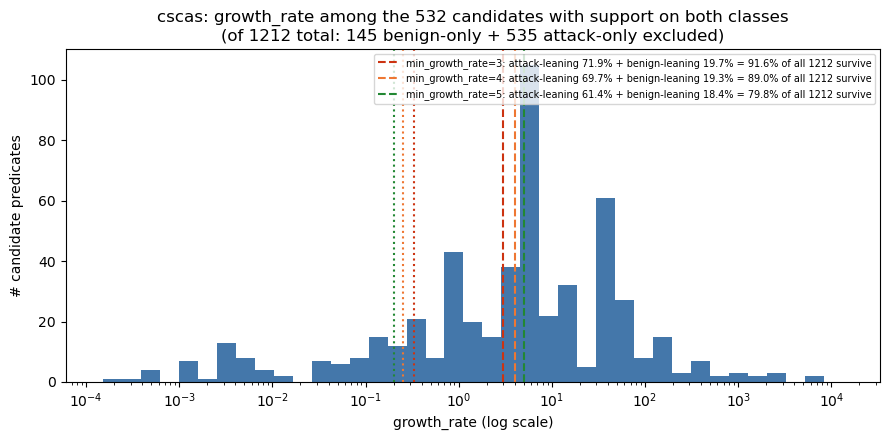

,threshold,n_attack_leaning,n_benign_leaning,n_survive_either,pct_of_all
0,0.5,956,328,1212,100.000000
1,1.0,921,291,1212,100.000000
2,1.5,896,262,1158,95.544554
3,2.0,884,256,1140,94.059406
4,2.5,872,255,1127,92.986799
5,3.0,871,239,1110,91.584158
6,4.0,845,234,1079,89.026403
7,5.0,744,223,967,79.785479
8,8.0,727,214,941,77.640264
9,10.0,711,207,918,75.742574


In [36]:
CURRENT_THRESHOLDS = [3.0, 4.0, 5.0]  # the existing screening_mining_settings.yaml / sweep_attribute_schema.sh grid

# contrast_stats no longer contains "dead" candidates (compute_predicate_
# contrast_stats drops them upstream now), but growth_rate is still not a
# single homogeneous population: a candidate with confidence_attack=0 has
# growth_rate=0 exactly (benign-only), and one with confidence_benign=0 has
# growth_rate = confidence_attack/eps -- a huge but essentially arbitrary
# finite number (attack-only), an artifact of the +eps smoothing rather than
# a meaningful magnitude. Only candidates with support on BOTH classes have
# a growth_rate that's a genuinely comparable ratio, and only for that
# group can min_growth_rate's specific value (3 vs. 4 vs. 5) ever change
# the outcome -- benign-only/attack-only candidates trivially clear their
# respective direction regardless of which of {3,4,5} is picked.
ca = contrast_stats["confidence_attack"]
cb = contrast_stats["confidence_benign"]
gr = contrast_stats["growth_rate"]

benign_only = (ca == 0) & (cb > 0)
attack_only = (ca > 0) & (cb == 0)
both_nonzero = (ca > 0) & (cb > 0)
n_total = len(contrast_stats)

print(f"benign-only (attack support = 0):           {benign_only.sum()}/{n_total} ({benign_only.mean()*100:.1f}%)")
print(f"attack-only (benign support = 0):           {attack_only.sum()}/{n_total} ({attack_only.mean()*100:.1f}%)")
print(f"both nonzero (growth_rate is a real ratio): {both_nonzero.sum()}/{n_total} ({both_nonzero.mean()*100:.1f}%)")

gr_both = gr[both_nonzero]

fig, ax = plt.subplots(figsize=(9, 4.5))
bins = np.logspace(np.log10(gr_both.min()), np.log10(gr_both.max()), 40)
ax.hist(gr_both, bins=bins, color="#4477AA")
ax.set_xscale("log")
ax.set_xlabel("growth_rate (log scale)")
ax.set_ylabel("# candidate predicates")
ax.set_title(
    f"cscas: growth_rate among the {both_nonzero.sum()} candidates with support on both classes\n"
    f"(of {n_total} total: {benign_only.sum()} benign-only + {attack_only.sum()} attack-only excluded)"
)

palette = ["#CC3311", "#EE7733", "#228833"]
for t, color in zip(CURRENT_THRESHOLDS, palette):
    attack_leaning = gr >= t
    benign_leaning = (cb > 0) & (gr <= 1.0 / t)
    pct_either = (attack_leaning | benign_leaning).mean() * 100
    ax.axvline(t, color=color, linestyle="--", linewidth=1.5,
               label=(f"min_growth_rate={t:g}: attack-leaning {attack_leaning.mean()*100:.1f}% "
                      f"+ benign-leaning {benign_leaning.mean()*100:.1f}% = {pct_either:.1f}% of all {n_total} survive"))
    ax.axvline(1.0 / t, color=color, linestyle=":", linewidth=1.5)
ax.legend(loc="upper right", fontsize=7)
plt.tight_layout()
plt.show()

# Finer-grained survival table, including thresholds well below the current
# grid, to see where the real "elbow" (the point candidate survival actually
# drops sharply) sits relative to {3.0, 4.0, 5.0} -- split by direction to
# match filter_contrast_survivors's either-side keep rule. Percentages are
# now of n_total (post dead-drop), not the old pre-fix 2933. Note this is
# growth_rate only; min_attack_coverage/min_benign_coverage gates aren't
# applied here.
survival = pd.DataFrame(
    [
        {
            "threshold": t,
            "n_attack_leaning": int((gr >= t).sum()),
            "n_benign_leaning": int(((cb > 0) & (gr <= 1.0 / t)).sum()),
            "n_survive_either": int(((gr >= t) | ((cb > 0) & (gr <= 1.0 / t))).sum()),
            "pct_of_all": (((gr >= t) | ((cb > 0) & (gr <= 1.0 / t))).mean()) * 100,
        }
        for t in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 8.0, 10.0, 50.0]
    ]
)
survival

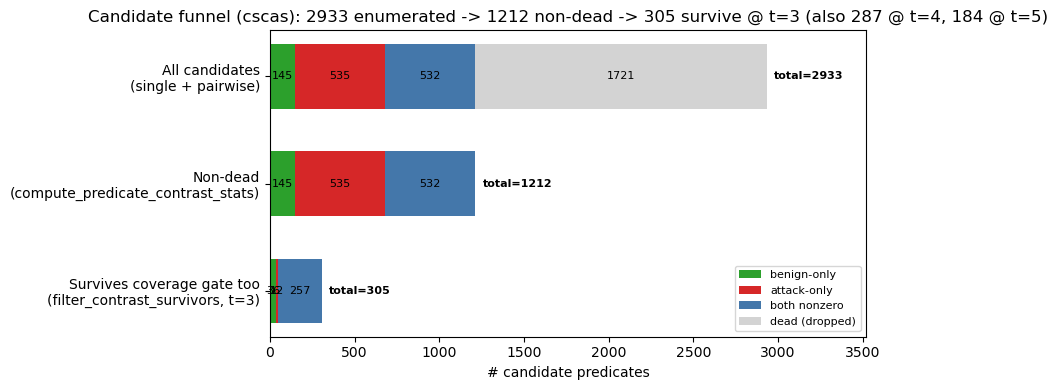

In [37]:
# Funnel: all enumerated single+pairwise candidates -> non-dead (dead
# dropped inside compute_predicate_contrast_stats itself, see section 17
# above) -> survives filter_contrast_survivors too (coverage gates +
# min_growth_rate). t=3.0 (the most permissive point in the swept grid) is
# the primary bar; t=4.0/5.0 are annotated in the title for comparison,
# since only the "both nonzero" segment's survivor count actually changes
# with the threshold (benign-only/attack-only survival is threshold-
# independent -- see section 17's discussion).
from thesis.mining.attribute_contrast_mining import filter_contrast_survivors

PRIMARY_THRESHOLD = 3.0
survivors = filter_contrast_survivors(contrast_stats, min_growth_rate=PRIMARY_THRESHOLD)
surv_ca = survivors["confidence_attack"]
surv_cb = survivors["confidence_benign"]

stages = [
    ("All candidates\n(single + pairwise)", {
        "benign-only": int(benign_only.sum()),
        "attack-only": int(attack_only.sum()),
        "both nonzero": int(both_nonzero.sum()),
        "dead (dropped)": n_dead_dropped,
    }),
    ("Non-dead\n(compute_predicate_contrast_stats)", {
        "benign-only": int(benign_only.sum()),
        "attack-only": int(attack_only.sum()),
        "both nonzero": int(both_nonzero.sum()),
    }),
    (f"Survives coverage gate too\n(filter_contrast_survivors, t={PRIMARY_THRESHOLD:g})", {
        "benign-only": int(((surv_ca == 0) & (surv_cb > 0)).sum()),
        "attack-only": int(((surv_ca > 0) & (surv_cb == 0)).sum()),
        "both nonzero": int(((surv_ca > 0) & (surv_cb > 0)).sum()),
    }),
]

seg_colors = {
    "benign-only": "tab:green",
    "attack-only": "tab:red",
    "both nonzero": "#4477AA",
    "dead (dropped)": "lightgrey",
}

fig, ax = plt.subplots(figsize=(9, 4))
for i, (label, segments) in enumerate(stages):
    y = len(stages) - 1 - i
    left = 0
    for seg_name, count in segments.items():
        ax.barh(y, count, left=left, color=seg_colors[seg_name], height=0.6,
                label=seg_name if i == 0 else None)
        if count > 0:
            ax.text(left + count / 2, y, f"{count}", ha="center", va="center", fontsize=8)
        left += count
    ax.text(left + n_candidates_total * 0.015, y, f"total={left}", va="center", fontsize=8, fontweight="bold")

ax.set_yticks([len(stages) - 1 - i for i in range(len(stages))])
ax.set_yticklabels([s[0] for s in stages])
ax.set_xlim(0, n_candidates_total * 1.2)
ax.set_xlabel("# candidate predicates")

n_survive_4 = len(filter_contrast_survivors(contrast_stats, min_growth_rate=4.0))
n_survive_5 = len(filter_contrast_survivors(contrast_stats, min_growth_rate=5.0))
ax.set_title(
    f"Candidate funnel (cscas): {n_candidates_total} enumerated -> {len(contrast_stats)} non-dead -> "
    f"{len(survivors)} survive @ t={PRIMARY_THRESHOLD:g} (also {n_survive_4} @ t=4, {n_survive_5} @ t=5)"
)
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

**Reading this**: if the survival percentage barely moves between `min_growth_rate=3.0` and `5.0` in the table above, that's a direct, data-level explanation for `config_selection.ipynb`'s eta²≈0.0002 finding — the swept range doesn't select meaningfully different candidate sets, so it can't have moved the downstream model either. If instead survival drops sharply somewhere well below `3.0` (e.g. near `1.0`–`1.5`, the neutral point where a predicate stops being attack-indicative at all), that's the region actually worth screening -- both for a future revision of `screening_mining_settings.yaml`'s grid, and as the `min_growth_rate` value to hold fixed for the `class_weight`/`min_samples_leaf` sweep points below (`sweep_attribute_schema.sh`).

## 17b. Contrast-Set Coverage Distribution

`min_attack_coverage` / `min_benign_coverage` (`ContrastSetFilterConfig` in
`thesis.schemas.mining`, defaults `0.05`/`0.05`) are the other two Step-1
thresholds in `filter_contrast_survivors` (`thesis.mining.
attribute_contrast_mining`), alongside `min_growth_rate` above. They have
never been swept, so there's no `parameter_importance` finding to check them
against -- this section is the same kind of "does the default sit near a
real elbow" look, but the shape of the problem is different from
growth_rate's:

- **Not exempt for benign-only/attack-only candidates.** Growth_rate only
  discriminated within the 43.9% "both nonzero" population -- benign-only /
  attack-only candidates cleared their growth_rate direction trivially.
  Coverage doesn't have that exemption: `_keep` checks
  `confidence_attack >= min_attack_coverage` for *any* attack-leaning
  candidate, including attack-only ones. So coverage prunes a much larger
  share of the pipeline than growth_rate does.
- **Sequential, not independent.** `min_attack_coverage` is only checked if
  `attack_leaning` (`growth_rate >= min_growth_rate`) is already true (same
  for benign). So the population below is "candidates that already passed
  growth_rate at the anchor threshold," not all of `contrast_stats`.
- **Separable by direction.** `attack_leaning` and `benign_leaning` are
  mutually exclusive, so `min_attack_coverage` / `min_benign_coverage` act on
  disjoint subpopulations and are swept as two independent 1D problems below.
- **`confidence_attack` / `confidence_benign` ARE the coverage metric**, not
  a separate quantity -- `predicate_support_stats` computes
  `attack_support = n_fires_attack / n_attack` against the dataset-wide
  attack alert-group count, and that becomes `confidence_attack` verbatim.
  `ca` / `cb` from Section 17 are reused directly below.
- **Class imbalance matters more here than for growth_rate**, since it sets
  the coverage denominator directly (see printed counts below).


**Confidence vs. coverage, concretely.** Three different per-candidate quantities get computed in `predicate_support_stats` / `compute_predicate_contrast_stats` (`thesis.mining.attribute_contrast_mining`), and it's easy to conflate them:

- **`confidence_attack` / `confidence_benign`** — per-class recall of the itemset:
  `attack_support = n_fires_attack / n_attack`, `benign_support = n_fires_benign / n_benign`
  i.e. *of all attack (resp. benign) alert-groups, what fraction does this itemset fire on.* Despite the name, this is **not** classical association-rule confidence (`P(class | itemset)`, a precision-like quantity) — that's never computed here. It's per-class coverage/recall, and as the bullet above says, it's the exact same field `min_attack_coverage`/`min_benign_coverage` filter on — "confidence" and "coverage" are two names for one number in this codebase, not two separate metrics.
- **`growth_rate`** — the ratio of the two: `attack_support / (benign_support + eps)`. This is what actually measures *discriminativeness* — how much more (or less) common the itemset is among attack groups vs. benign groups. `ca_pool`/`cb_pool` below are `confidence_attack`/`confidence_benign` restricted to whichever side of the `growth_rate` gate (`attack_leaning`/`benign_leaning`) they're on.
- **`support`** (used in Section 17/18, *not* in the pools below) — `support_count / n_total`, the fraction of the *whole* population (attack + benign combined) that fires the itemset. This is the classical association-rule support and is not class-conditional at all — don't confuse it with `confidence_attack`/`confidence_benign`, and it's unrelated to the "coverage%" (`notna().mean()`, data completeness) used earlier in this notebook (Section 7).

- **`precision_attack`** (new, added to `compute_predicate_contrast_stats`'s output) — the classical association-rule confidence: `n_fires_attack / (n_fires_attack + n_fires_benign)` = `P(class=attack | itemset fires)`. This is the "if this rule fires, how trustworthy is the alert" number, and it is imbalance-sensitive by design (the huge benign population in this dataset drags it down even for attack-specific patterns) -- unlike `confidence_attack`/`growth_rate`, which normalize each class against its own size. It is diagnostic only: `filter_contrast_survivors` and the dynamic schema still gate on `growth_rate`/coverage, not on this.

In [38]:
ANCHOR_GROWTH_RATE = 3.0  # matches PRIMARY_THRESHOLD from section 17, In[44] -- the most permissive point in the swept {3,4,5} grid


attack_leaning = gr >= ANCHOR_GROWTH_RATE
benign_leaning = (cb > 0) & (gr <= 1.0 / ANCHOR_GROWTH_RATE)

ca_pool = ca[attack_leaning]  # confidence_attack among attack-leaning survivors of the growth_rate gate
cb_pool = cb[benign_leaning]  # confidence_benign among benign-leaning survivors of the growth_rate gate

n_attack_groups = int((y_ag == 1).sum())
n_benign_groups = int((y_ag == 0).sum())

# attack_only/benign_only/both_nonzero come from section 17 (In[43]) -- attack_leaning is
# exactly attack_only (growth_rate is huge whenever confidence_benign == 0) plus whichever
# both_nonzero candidates clear the threshold, and symmetrically for benign_leaning.
n_attack_both = int((attack_leaning & both_nonzero).sum())
n_benign_both = int((benign_leaning & both_nonzero).sum())

print(f"attack-leaning pool ({attack_leaning.sum()}) = {attack_only.sum()} attack-only (all of them, automatically) "
      f"+ {n_attack_both} both-nonzero candidates with growth_rate >= {ANCHOR_GROWTH_RATE:g}")
print(f"benign-leaning pool ({benign_leaning.sum()}) = {benign_only.sum()} benign-only (all of them, automatically) "
      f"+ {n_benign_both} both-nonzero candidates with growth_rate <= {1.0 / ANCHOR_GROWTH_RATE:.3g}")
print()
print(f"dataset-wide attack alert-groups: {n_attack_groups:,}")
print(f"dataset-wide benign alert-groups: {n_benign_groups:,}")
print(f"imbalance: 1 attack : {n_benign_groups / n_attack_groups:.1f} benign")


attack-leaning pool (871) = 535 attack-only (all of them, automatically) + 336 both-nonzero candidates with growth_rate >= 3
benign-leaning pool (239) = 145 benign-only (all of them, automatically) + 94 both-nonzero candidates with growth_rate <= 0.333

dataset-wide attack alert-groups: 20,952
dataset-wide benign alert-groups: 1,374,372
imbalance: 1 attack : 65.6 benign


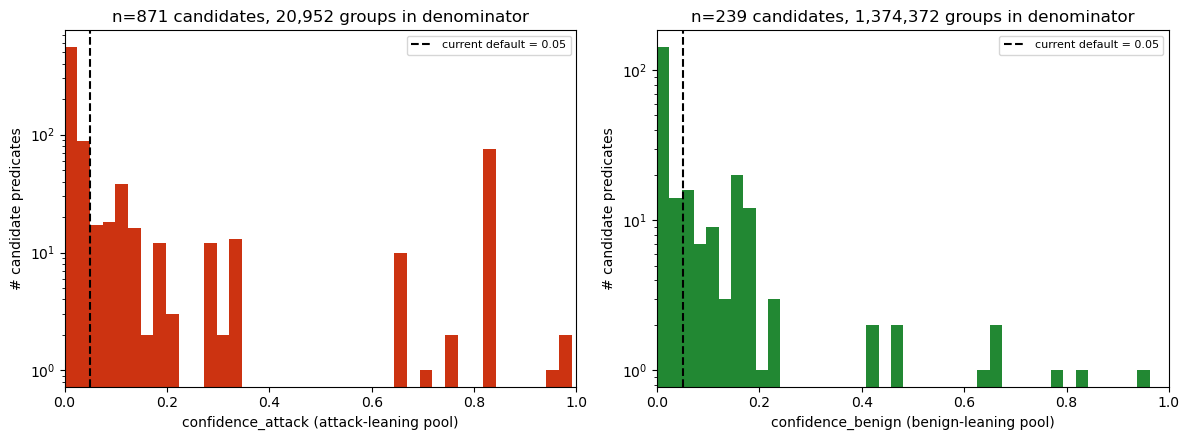

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, pool, label, color, n_groups in [
    (axes[0], ca_pool, "confidence_attack (attack-leaning pool)", "#CC3311", n_attack_groups),
    (axes[1], cb_pool, "confidence_benign (benign-leaning pool)", "#228833", n_benign_groups),
]:
    ax.hist(pool, bins=40, color=color)
    ax.axvline(0.05, color="black", linestyle="--", linewidth=1.5, label="current default = 0.05")
    ax.set_xlabel(label)
    ax.set_ylabel("# candidate predicates")
    ax.set_xlim(0, 1)
    ax.set_title(f"n={len(pool)} candidates, {n_groups:,} groups in denominator")
    ax.set_yscale("log")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Reading the table below**: `n_attack_groups`/`n_benign_groups` (the
coverage denominators) are both large (20,952 / 1,374,372), so granularity
of the coverage metric itself isn't the bottleneck here -- unlike a small
dataset where coverage could only take values that are multiples of
`1/n_groups`. The actual noise source is pool *size*: the benign-leaning
pool has far fewer candidates than the attack-leaning one, so
`pct_benign_survive` is expected to step more coarsely/noisily than
`pct_attack_survive`. Don't over-read fine "elbows" on the benign side with
only a few hundred candidates behind each percentage.


In [40]:
COVERAGE_GRID = [0.0, 0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30, 0.50, 0.75, 0.90, 0.95, 0.99, 1.0]

coverage_survival = pd.DataFrame(
    [
        {
            "threshold": t,
            "n_attack_survive": int((ca_pool >= t).sum()),
            "pct_attack_survive": (ca_pool >= t).mean() * 100,
            "n_benign_survive": int((cb_pool >= t).sum()),
            "pct_benign_survive": (cb_pool >= t).mean() * 100,
        }
        for t in COVERAGE_GRID
    ]
)
coverage_survival


,threshold,n_attack_survive,pct_attack_survive,n_benign_survive,pct_benign_survive
0,0.00,871,100.000000,239,100.000000
1,0.01,346,39.724455,114,47.698745
2,0.02,337,38.691160,95,39.748954
3,0.03,309,35.476464,93,38.912134
4,0.05,224,25.717566,81,33.891213
5,0.08,206,23.650976,65,27.196653
6,0.10,189,21.699196,50,20.920502
7,0.15,134,15.384615,45,18.828452
8,0.20,121,13.892078,13,5.439331
9,0.30,106,12.169920,10,4.184100


In [41]:
# Joint sweep: full min_growth_rate x coverage grid, closing out the growth_rate
# (section 17) and coverage (section 17b) analyses above by looking at both
# axes together instead of one fixed default against the other. Supersedes
# the narrower CURRENT_THRESHOLDS x 0.05 check this cell used to run --
# COVERAGE_GRID is the same grid defined above; GROWTH_RATE_GRID is new and
# spans well below the swept {3,4,5} region (down to the neutral point at
# 1.0) and well above it, so both grids can be picked from one joint view.
from IPython.display import display

GROWTH_RATE_GRID = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 8.0, 10.0, 50.0]

interaction_rows = []
for t in GROWTH_RATE_GRID:
    al = gr >= t
    bl = (cb > 0) & (gr <= 1.0 / t)
    ca_t = ca[al]
    cb_t = cb[bl]
    for c in COVERAGE_GRID:
        interaction_rows.append(
            {
                "min_growth_rate": t,
                "coverage_threshold": c,
                "n_attack_pool": int(al.sum()),
                "n_benign_pool": int(bl.sum()),
                "n_attack_survive": int((ca_t >= c).sum()),
                "pct_attack_survive": (ca_t >= c).mean() * 100,
                "n_benign_survive": int((cb_t >= c).sum()),
                "pct_benign_survive": (cb_t >= c).mean() * 100,
            }
        )

interaction_grid = pd.DataFrame(interaction_rows)

# Pivoted views easier to spot a joint elbow across both parameters than
# the 176-row long form above: rows = min_growth_rate, columns =
# coverage_threshold, cells = % of that growth_rate pool surviving that
# coverage cut.
attack_survival_grid = interaction_grid.pivot(
    index="min_growth_rate", columns="coverage_threshold", values="pct_attack_survive"
).round(1)
benign_survival_grid = interaction_grid.pivot(
    index="min_growth_rate", columns="coverage_threshold", values="pct_benign_survive"
).round(1)

print("% of attack-leaning pool surviving min_attack_coverage (rows=min_growth_rate, cols=min_attack_coverage):")
display(attack_survival_grid)
print()
print("% of benign-leaning pool surviving min_benign_coverage (rows=min_growth_rate, cols=min_benign_coverage):")
display(benign_survival_grid)

% of attack-leaning pool surviving min_attack_coverage (rows=min_growth_rate, cols=min_attack_coverage):


coverage_threshold,0.00,0.01,0.02,0.03,0.05,0.08,0.10,0.15,0.20,0.30,0.50,0.75,0.90,0.95,0.99,1.00
min_growth_rate,,,,,,,,,,,,,,,,
0.5,100.0,42.7,41.0,36.9,26.6,23.2,21.2,15.4,12.8,11.2,9.5,8.2,0.3,0.3,0.1,0.0
1.0,100.0,41.0,39.8,36.8,27.5,24.1,22.0,16.0,13.2,11.6,9.9,8.5,0.3,0.3,0.1,0.0
1.5,100.0,40.4,39.4,36.3,26.7,24.6,22.4,16.3,13.6,11.9,10.2,8.7,0.3,0.3,0.1,0.0
2.0,100.0,40.5,39.5,36.3,26.7,24.7,22.6,16.4,13.7,12.0,10.3,8.8,0.3,0.3,0.1,0.0
2.5,100.0,39.8,38.8,35.6,25.8,23.7,21.7,15.4,13.9,12.2,10.4,8.9,0.3,0.3,0.1,0.0
3.0,100.0,39.7,38.7,35.5,25.7,23.7,21.7,15.4,13.9,12.2,10.4,9.0,0.3,0.3,0.1,0.0
4.0,100.0,39.2,38.1,34.9,25.0,24.3,22.2,15.9,14.3,12.5,10.8,9.2,0.4,0.4,0.1,0.0
5.0,100.0,30.9,29.8,26.2,14.9,14.2,13.4,6.2,5.8,3.8,3.4,1.7,0.4,0.4,0.1,0.0
8.0,100.0,29.3,28.2,24.6,13.1,12.4,11.6,5.6,5.5,3.7,3.3,1.7,0.3,0.3,0.1,0.0



% of benign-leaning pool surviving min_benign_coverage (rows=min_growth_rate, cols=min_benign_coverage):


coverage_threshold,0.00,0.01,0.02,0.03,0.05,0.08,0.10,0.15,0.20,0.30,0.50,0.75,0.90,0.95,0.99,1.00
min_growth_rate,,,,,,,,,,,,,,,,
0.5,100.0,54.3,46.3,45.4,37.8,21.3,16.5,14.3,4.0,3.0,1.8,0.9,0.3,0.3,0.0,0.0
1.0,100.0,54.6,46.4,45.4,37.1,23.0,17.5,15.5,4.5,3.4,2.1,1.0,0.3,0.3,0.0,0.0
1.5,100.0,50.4,42.4,41.6,36.6,25.6,19.5,17.2,5.0,3.8,2.3,1.1,0.4,0.4,0.0,0.0
2.0,100.0,49.6,42.2,41.4,36.7,25.8,19.5,17.6,5.1,3.9,2.3,1.2,0.4,0.4,0.0,0.0
2.5,100.0,49.4,42.0,41.2,36.5,25.5,19.6,17.6,5.1,3.9,2.4,1.2,0.4,0.4,0.0,0.0
3.0,100.0,47.7,39.7,38.9,33.9,27.2,20.9,18.8,5.4,4.2,2.5,1.3,0.4,0.4,0.0,0.0
4.0,100.0,46.6,38.5,37.6,32.5,26.9,20.5,18.4,5.1,4.3,2.6,1.3,0.4,0.4,0.0,0.0
5.0,100.0,47.1,39.0,38.1,32.7,26.9,21.1,19.3,5.4,4.5,2.7,1.3,0.4,0.4,0.0,0.0
8.0,100.0,46.7,38.8,37.9,32.2,27.1,21.0,19.6,5.1,4.2,2.3,1.4,0.5,0.5,0.0,0.0


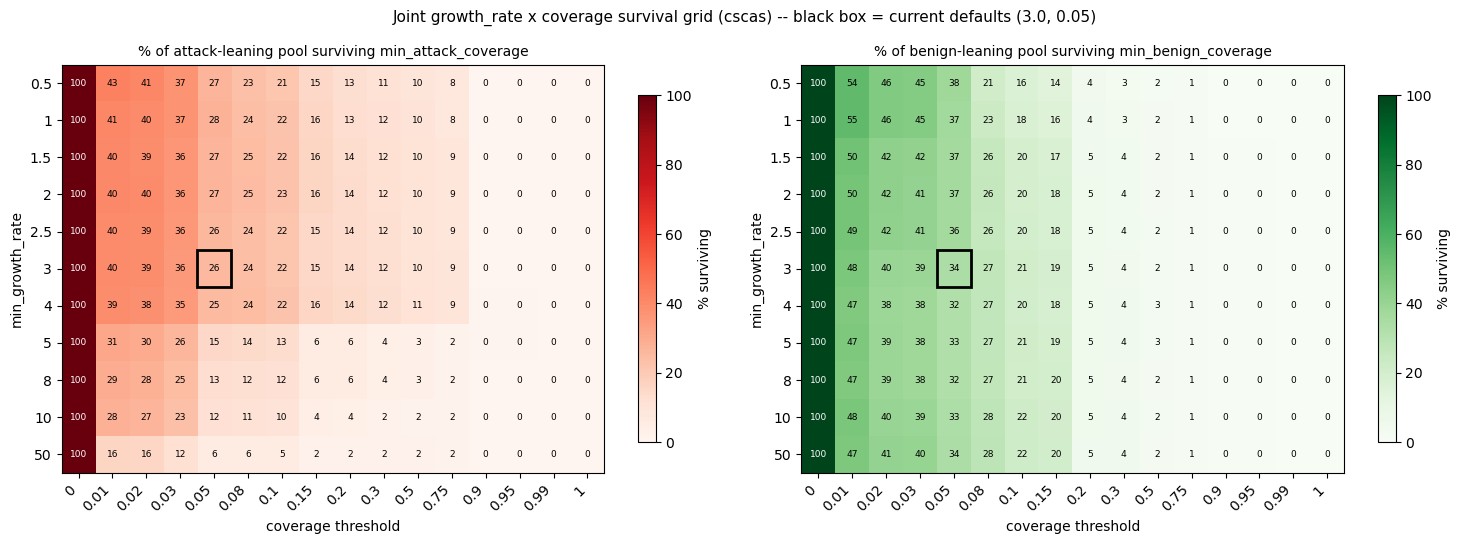

In [42]:
# Heatmap version of the candidate funnel's final "survives" stage, across
# the full (min_growth_rate, coverage) grid from the joint sweep above --
# extends the funnel plot's single t=3.0 bar (section 17) to the whole grid,
# without trying to draw 176 separate 3-segment funnels. Sequential single-hue
# ramps (red/green), matching this notebook's existing attack=red / benign=green
# convention (funnel plot and section 17b histograms above) rather than a
# rainbow colormap.
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

heatmap_specs = [
    (axes[0], attack_survival_grid, "Reds", "% of attack-leaning pool surviving min_attack_coverage"),
    (axes[1], benign_survival_grid, "Greens", "% of benign-leaning pool surviving min_benign_coverage"),
]

for ax, grid, cmap, title in heatmap_specs:
    im = ax.imshow(grid.to_numpy(), cmap=cmap, vmin=0, vmax=100, aspect="auto")
    ax.set_xticks(range(len(grid.columns)))
    ax.set_xticklabels([f"{c:g}" for c in grid.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(grid.index)))
    ax.set_yticklabels([f"{r:g}" for r in grid.index])
    ax.set_xlabel("coverage threshold")
    ax.set_ylabel("min_growth_rate")
    ax.set_title(title, fontsize=10)

    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            val = grid.iat[i, j]
            ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=6.5,
                     color="white" if val > 55 else "black")

    # Current shipped defaults (ContrastSetFilterConfig / screening_mining_settings.yaml):
    # min_growth_rate=3.0, min_attack_coverage=min_benign_coverage=0.05
    if 3.0 in grid.index and 0.05 in grid.columns:
        gi = list(grid.index).index(3.0)
        gj = list(grid.columns).index(0.05)
        ax.add_patch(plt.Rectangle((gj - 0.5, gi - 0.5), 1, 1, fill=False, edgecolor="black", linewidth=2))

    fig.colorbar(im, ax=ax, label="% surviving", shrink=0.85)

fig.suptitle("Joint growth_rate x coverage survival grid (cscas) -- black box = current defaults (3.0, 0.05)", fontsize=11)
plt.tight_layout()
plt.show()

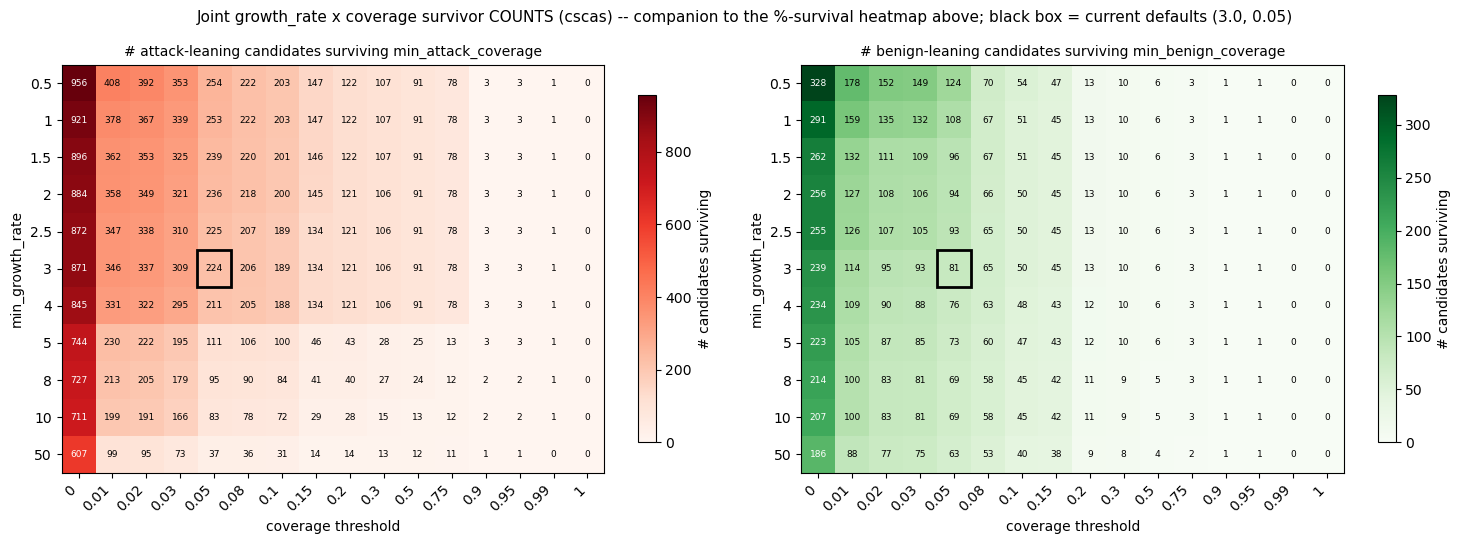

In [43]:
# Raw-count companion to the %-survival heatmap above. growth_rate's effect
# on pool *size* is real, it's just invisible in a percentage table once
# coverage_threshold=0 is a no-op filter -- every row there reads 100%
# regardless of growth_rate, because each percentage is relative to that
# row's own already-shrunk pool (attack_leaning = gr >= t), not a fixed
# universe of candidates. This plots the raw n_attack_survive/n_benign_survive
# counts instead, where growth_rate's shrinkage of the pool is directly
# visible (unlike the %-heatmap, each panel gets its own color scale here --
# raw counts aren't naturally comparable 0..100 the way percentages are).
n_attack_survive_grid = interaction_grid.pivot(
    index="min_growth_rate", columns="coverage_threshold", values="n_attack_survive"
)
n_benign_survive_grid = interaction_grid.pivot(
    index="min_growth_rate", columns="coverage_threshold", values="n_benign_survive"
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

count_heatmap_specs = [
    (axes[0], n_attack_survive_grid, "Reds", "# attack-leaning candidates surviving min_attack_coverage"),
    (axes[1], n_benign_survive_grid, "Greens", "# benign-leaning candidates surviving min_benign_coverage"),
]

for ax, grid, cmap, title in count_heatmap_specs:
    vmax = int(grid.to_numpy().max())
    im = ax.imshow(grid.to_numpy(), cmap=cmap, vmin=0, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(grid.columns)))
    ax.set_xticklabels([f"{c:g}" for c in grid.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(grid.index)))
    ax.set_yticklabels([f"{r:g}" for r in grid.index])
    ax.set_xlabel("coverage threshold")
    ax.set_ylabel("min_growth_rate")
    ax.set_title(title, fontsize=10)

    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            val = int(grid.iat[i, j])
            ax.text(j, i, f"{val:d}", ha="center", va="center", fontsize=6.5,
                     color="white" if val > vmax * 0.55 else "black")

    # Current shipped defaults (ContrastSetFilterConfig / screening_mining_settings.yaml):
    # min_growth_rate=3.0, min_attack_coverage=min_benign_coverage=0.05
    if 3.0 in grid.index and 0.05 in grid.columns:
        gi = list(grid.index).index(3.0)
        gj = list(grid.columns).index(0.05)
        ax.add_patch(plt.Rectangle((gj - 0.5, gi - 0.5), 1, 1, fill=False, edgecolor="black", linewidth=2))

    fig.colorbar(im, ax=ax, label="# candidates surviving", shrink=0.85)

fig.suptitle("Joint growth_rate x coverage survivor COUNTS (cscas) -- companion to the %-survival heatmap "
             "above; black box = current defaults (3.0, 0.05)", fontsize=11)
plt.tight_layout()
plt.show()

## 18. Raw Field Discriminativeness (Categorical, Numerical, Mutual Information)

Section 17 covers `growth_rate`, computed per *predicate value* once contrast-set
mining has already enumerated candidates. This section steps one level up: for
each raw *field* on an `AlertGroup` (before any mining, one-hot expansion, or
threshold), how much signal does it carry about the label on its own?

- **Categorical fields** (`category`, `ruleset`, `proto`, `scas`, `cve_present`,
  ...): for each value `v` a field can take, the local attack rate
  `p_v = P(attack | field=v)` compared against the dataset base rate, summarized
  per-field by **Cramér's V** (a chi-square-derived association score, 0-1,
  comparable across fields regardless of how many values each takes).
- **Numeric fields** (`similarity`, `signature_matches_per_day`, `cve_age_years`,
  ...): **point-biserial correlation** (Pearson correlation against the binary
  label) and **AUC-based separability** (the field's raw value used directly as
  a 1-D classifier score) -- two complementary reads on the same relationship.
- **Mutual information** `I(field; Label)` unifies both: an encoding-agnostic
  measure that captures any statistical dependency, not only the
  monotonic/single-threshold relationships the measures above are each
  individually sensitive to.

All four are implemented in `thesis.metrics.field_discriminativeness` and computed
directly on the raw fields via `compute_candidate_attribute_features` (the same
per-`AlertGroup` extractor mining itself uses, reused here rather than
re-derived, via `thesis.mining.attribute_features` -- so this EDA never drifts
out of sync with what mining actually consumes).

These stats characterize the *raw data*, independent of any mining
configuration -- they cannot say what a particular mining strategy, with its
own filters and thresholds, will ultimately extract. The interpretation cell at
the end flags which raw fields look most promising ahead of mining, to be
revisited later against the mining pipeline's actual output.

In [44]:
# from thesis.mining.attribute_features import (
#     BINARY_CATEGORICAL_FIELDS,
#     MULTI_VALUED_CATEGORICAL_FIELDS,
#     NUMERIC_FIELDS,
#     compute_candidate_attribute_features,
# )
# from thesis.schemas.preprocessing import ATTR_SIMILARITY_COLUMNS

# # The "core" interpretable fields for the headline plots below -- the
# # namespaced qualifier_*/attr_populated:*/attr_value:*/applicable_layer:*
# # expansions in BINARY_CATEGORICAL_FIELDS/NUMERIC_FIELDS are left to the full
# # mutual-information table further down instead, to keep these plots readable.
# CORE_CATEGORICAL_FIELDS = list(MULTI_VALUED_CATEGORICAL_FIELDS) + [
#     "cve_present", "multi_target", "multi_ext_port", "multi_int_port", "proto_mismatch",
# ]
# CORE_NUMERIC_FIELDS = [
#     "signature_matches_per_day", "alert_count", "similarity", "signature_id_similarity", "cve_age_years",
# ]

# # -1.0 is this codebase's "not applicable" sentinel for numeric attribute
# # features (thesis.mining.attribute_features._NOT_APPLICABLE) -- only
# # cve_age_years and the attr_value:* columns actually use it; the other
# # numeric fields default to 0.0 (a real value), not -1.
# NUMERIC_SENTINELS = {
#     "cve_age_years": -1.0,
#     **{f"attr_value:{name}": -1.0 for name in ATTR_SIMILARITY_COLUMNS},
# }

# # One pass over cscas_alert_groups (loaded in section 17 above), reusing the
# # same single-source-of-truth extractor mining itself calls.
# #
# # compute_candidate_attribute_features is a per-alert_group Python call, not
# # vectorized -- over the full ~1.4M cscas_alert_groups that loop alone took
# # ~237s measured directly. Sampled down to FIELD_DF_SAMPLE_SIZE first: the
# # cramers_v/point_biserial_r/auc_separability/mutual_information scores
# # below all came out within ~0.01 of their full-population values on a
# # 200k check against this exact data, so there's nothing here that needs
# # every row. Sampling into a new list rather than reassigning
# # cscas_alert_groups itself, so re-running section 17's cells later (even
# # out of order) still sees the full population, not this smaller one.
# FIELD_DF_SAMPLE_SIZE = 200_000
# if len(cscas_alert_groups) > FIELD_DF_SAMPLE_SIZE:
#     import random
#     alert_groups_for_fields = random.Random(0).sample(cscas_alert_groups, FIELD_DF_SAMPLE_SIZE)
# else:
#     alert_groups_for_fields = cscas_alert_groups

# field_rows = [compute_candidate_attribute_features(tx) for tx in alert_groups_for_fields]
# field_df = pd.DataFrame(field_rows)
# field_df["Label"] = [1 if tx.group_label == "attack" else 0 for tx in alert_groups_for_fields]

# print(f"{len(field_df)} alert_groups (sampled from {len(cscas_alert_groups)}), base attack rate {field_df['Label'].mean() * 100:.2f}%")
# field_df[CORE_CATEGORICAL_FIELDS + CORE_NUMERIC_FIELDS].describe(include="all").T

In [45]:
# from IPython.display import display

# from thesis.metrics.field_discriminativeness import cramers_v, local_attack_rates

# cramers_v_scores = pd.Series(
#     {field: cramers_v(field_df[field], field_df["Label"]) for field in CORE_CATEGORICAL_FIELDS}
# ).sort_values(ascending=False)

# fig, ax = plt.subplots(figsize=(8, 5))
# ax.barh(cramers_v_scores.index, cramers_v_scores.values, color="#4477AA")
# ax.set_xlabel("Cramér's V")
# ax.set_title("Categorical field discriminativeness (Cramér's V vs. Label)")
# ax.invert_yaxis()
# plt.tight_layout()
# plt.show()

# # Local attack rate vs. base rate for the two strongest fields' values.
# for field in cramers_v_scores.index[:2]:
#     rates = local_attack_rates(field_df, field, "Label")
#     print(f"\n{field} (Cramér's V={cramers_v_scores[field]:.3f}, base rate {rates['base_rate'].iloc[0]:.3f}):")
#     display(rates.head(10)[["value", "support", "attack_rate", "deviation"]])

In [46]:
# from thesis.metrics.field_discriminativeness import auc_separability, point_biserial_score

# numeric_rows = []
# for field in CORE_NUMERIC_FIELDS:
#     sentinel = NUMERIC_SENTINELS.get(field)
#     r, p = point_biserial_score(field_df[field], field_df["Label"], sentinel=sentinel)
#     auc = auc_separability(field_df[field], field_df["Label"], sentinel=sentinel)
#     numeric_rows.append({"field": field, "point_biserial_r": r, "p_value": p, "auc_separability": auc})
# numeric_scores = pd.DataFrame(numeric_rows).sort_values("auc_separability", ascending=False)

# fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# colors = ["red" if v < 0 else "steelblue" for v in numeric_scores["point_biserial_r"]]
# axes[0].barh(numeric_scores["field"], numeric_scores["point_biserial_r"], color=colors)
# axes[0].axvline(0, color="black", linewidth=0.8)
# axes[0].set_title("Point-biserial correlation with Label")
# axes[0].set_xlabel("r")

# axes[1].barh(numeric_scores["field"], numeric_scores["auc_separability"], color="#4477AA")
# axes[1].axvline(0.5, color="black", linewidth=0.8, linestyle="--", label="no separation (0.5)")
# axes[1].set_title("AUC-based separability")
# axes[1].set_xlabel("max(AUC, 1-AUC)")
# axes[1].set_xlim(0.4, 1.0)
# axes[1].legend(fontsize=8)

# for ax in axes:
#     ax.invert_yaxis()
# plt.tight_layout()
# plt.show()

# numeric_scores

In [ ]:
# from thesis.metrics.field_discriminativeness import field_discriminativeness_table

# # The full field set this time -- including the namespaced qualifier_*/
# # attr_populated:*/attr_value:*/applicable_layer:* expansions skipped above.
# ALL_CATEGORICAL_FIELDS = list(MULTI_VALUED_CATEGORICAL_FIELDS) + list(BINARY_CATEGORICAL_FIELDS)
# ALL_NUMERIC_FIELDS = list(NUMERIC_FIELDS)

# mi_table = field_discriminativeness_table(
#     field_df,
#     categorical_fields=ALL_CATEGORICAL_FIELDS,
#     numeric_fields=ALL_NUMERIC_FIELDS,
#     label_col="Label",
#     sentinels=NUMERIC_SENTINELS,
# )
# print(f"{len(mi_table)} raw fields ranked by mutual information with Label")

# # One bar per field, in mi_table's own descending order -- with ~90 fields,
# # figure height and label font both scale with the row count so labels stay
# # legible instead of overlapping.
# n_fields = len(mi_table)
# fig, ax = plt.subplots(figsize=(9, max(6, 0.22 * n_fields)))
# colors = ["#CC3311" if t == "categorical" else "#4477AA" for t in mi_table["field_type"]]
# ax.barh(mi_table["field"], mi_table["mutual_information"], color=colors)
# ax.invert_yaxis()
# ax.tick_params(axis="y", labelsize=max(5, min(9, 400 / n_fields)))
# ax.set_xlabel("Mutual information I(field; Label)")
# ax.set_title(f"All {n_fields} raw fields by mutual information with Label")
# ax.legend(
#     handles=[
#         plt.Rectangle((0, 0), 1, 1, color="#CC3311", label="categorical"),
#         plt.Rectangle((0, 0), 1, 1, color="#4477AA", label="numeric"),
#     ],
#     loc="lower right",
# )
# plt.tight_layout()
# plt.show()

# mi_table.head(20)

: 

**Reading this**: `mutual_information` is the one score comparable across
categorical and numeric fields alike, so it's the ranking to lead with; Cramér's
V / point-biserial r / AUC separability explain *how* a given field is
informative (association strength, direction, and single-threshold
separability, respectively) once MI has flagged it as worth a closer look. The
fields at the top of this ranking are exactly the raw signal
`compute_predicate_contrast_stats` (section 17) and the decision-tree rule
extraction step have to work with -- **revisit this ranking later against the
mining pipeline's actual output** (e.g. `attribute_mining_sweep_eda.ipynb`'s
mined-schema composition) to see how well raw-field discriminativeness
anticipated what mining actually kept.